<a href="https://colab.research.google.com/github/nikhilkanamadi/High-signal-first-Principles-for-cancer-research-using-Python./blob/Notebook/Python_for_Cancer_Researchers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧬 **The Varambally Lab Computational Suite**
### *From Genomic First Principles to Deep Intuition in AI Pathology*

---

## **🎯 Research Mission**
This notebook series is designed to operationalize the **High-Signal Strategy** for cancer research. It bridges the gap between raw molecular data (TCGA/CPTAC) and clinical application, focusing on the specific challenges of **Prostate Cancer**, **Health Disparities**, and **Biomarker Discovery** (*EZH2, AMACR, TMPRSS2-ERG*).

## **🧠 The 4 Core Pillars**
We apply **First Principles Thinking** to biological data:

### **1. ⚛️ First Principles (The Physics)**
* **Concept:** Cancer is not chaos; it is an information error (Entropy).
* **Application:** Modeling gene fusions (*TMPRSS2-ERG*) as "syntax errors" in the genomic code and treating expression data as physical signals that must be filtered.

### **2. 📊 Quantization (The Signal)**
* **Concept:** Biology is noisy; Data is the filter.
* **Application:** Using rigorous statistical thresholds (Fold Change $> 1.5$, $p < 0.05$) to **quantize** continuous biological noise into binary clinical signals (Driver vs. Passenger).

### **3. 🕸️ Systems Connectivity (The Network)**
* **Concept:** Phenotypes are emergent properties of networks, not single genes.
* **Application:** Mapping "Hub Genes" and co-expression modules to understand how a single target (like *EZH2*) controls vast proliferation networks.

### **4. 👁️ Deep Intuition (The Vision)**
* **Concept:** Hierarchical abstraction mimics the pathologist's eye.
* **Application:** Using **ResNet-50** and **Transfer Learning** to automatically identify high-grade tumor architecture in gigapixel Whole Slide Images (WSI), removing human bias through **Color Normalization**.

---

## **🛠️ Computational Toolset**
* **Genomics:** `BioPython`, `Pandas`, `NumPy` (Vectorization)
* **Statistics:** `SciPy`, `Statsmodels`, `Lifelines` (Survival Analysis)
* **Visualization:** `Seaborn`, `Matplotlib` (Publication-Ready Figures)
* **AI/Vision:** `PyTorch`, `OpenSlide`, `Scikit-Image`

---
> **👨‍🔬 User Note:** Run the cells sequentially. Each module begins with a **"First Principle"** explanation to ground the code in biological reality.

# 🧬 Notebook 01: The Physics of Gene Fusions
## First Principle: Information Entropy & Corruption
* **Concept:** The genome is an ordered information system ($S$). Cancer is not "chaos"; it is a specific type of **syntax error** where two independent logic gates (Genes A & B) are wired together.
* **The Math:** A fusion event is a concatenation operation $F(S_A, S_B) \rightarrow S_{fusion}$. For this to be pathogenic, the **Open Reading Frame (ORF)** must be preserved: $(|S_A| + |S_B|) \pmod 3 = 0$.
* **High Signal Takeaway:** We are not just looking for "mutations"; we are looking for **neomorphic functionality**—a new protein that never existed in nature, created by a wiring error (e.g., *TMPRSS2-ERG*).

In [ ]:
# Install biopython if not present
!pip install biopython

from Bio.Seq import Seq
from Bio.SeqUtils import gc_fraction # To calculate "Physical" properties of DNA
print("Biopython loaded successfully.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 23.0 MB/s eta 0:00:00
Biopython loaded successfully.


In [ ]:
# TMPRSS2 Segment (The "Switch")
# In reality, this is thousands of bases long. We use a representative segment.
tmprss2 = Seq("GGCAGGCGCGGAGCCGGTGC")

# ERG Segment (The "Oncogene")
# This is the driver of uncontrolled growth.
erg = Seq("ATGATACAGAGAAATAATT")

print(f"TMPRSS2 Switch Segment: {tmprss2}")
print(f"ERG Oncogene Segment:   {erg}")

TMPRSS2 Switch Segment: GGCAGGCGCGGAGCCGGTGC
ERG Oncogene Segment:   ATGATACAGAGAAATAATT


In [ ]:
# Simulating the breakpoint at the end of TMPRSS2 exon 1 and start of ERG exon 4
fusion_gene = tmprss2 + erg

print("-" * 30)
print(f"CHIMERIC FUSION GENE: {fusion_gene}")
print(f"Total Length: {len(fusion_gene)} base pairs")

------------------------------
CHIMERIC FUSION GENE: GGCAGGCGCGGAGCCGGTGCATGATACAGAGAAATAATT
Total Length: 39 base pairs


In [ ]:
# DNA -> RNA
messenger_rna = fusion_gene.transcribe()

print(f"mRNA Message: {messenger_rna}")
# Note how 'T' (Thymine) is replaced with 'U' (Uracil)

mRNA Message: GGCAGGCGCGGAGCCGGUGCAUGAUACAGAGAAAUAAUU


In [ ]:
# RNA -> Protein
# We use the 'Standard' genetic code table.
try:
    fusion_protein = messenger_rna.translate()
    print(f"Resulting Fusion Protein: {fusion_protein}")
except Exception as e:
    print(f"Error in translation: {e}")

# KEYWORD: 'Stop Codon' (*)
# If a * appears in the middle, the fusion is likely 'unproductive' (broken).

Resulting Fusion Protein: GRRGAGA*YREII


In [ ]:
# Let's compare the GC-content (Physical stability) of the parent vs fusion
gc_tmprss2 = gc_fraction(tmprss2) * 100
gc_erg = gc_fraction(erg) * 100
gc_fusion = gc_fraction(fusion_gene) * 100

print(f"TMPRSS2 GC Content: {gc_tmprss2:.2f}%")
print(f"ERG GC Content:     {gc_erg:.2f}%")
print(f"Fusion GC Content:  {gc_fusion:.2f}%")

TMPRSS2 GC Content: 85.00%
ERG GC Content:     21.05%
Fusion GC Content:  53.85%


# 📊 Notebook 02: Matrix Quantization & UALCAN Logic
## First Principle: Signal Extraction from Noise
* **Concept:** Biological data is noisy (stochastic). A single patient is anecdotal; a cohort of 500 is a **statistical distribution**. We treat the expression matrix $E \in \mathbb{R}^{G \times P}$ as a signal processing problem.
* **The Math:** We calculate the **Fold Change (FC)** as the ratio of signal intensities:
    $$FC = \log_2\left(\frac{\mu_{tumor}}{\mu_{normal}}\right)$$
* **High Signal Takeaway:** Dr. Varambally's "Deep Intuition" relies on **Differential Expression**. If a gene is consistently upregulated across 1,000 diverse patients, it is a **Driver**, not a Passenger.

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Generating a synthetic dataset that mimics UALCAN's CPTAC/TCGA structure
# This ensures you can run the code immediately without needing external file access.
print("Environment initialized for Omics Analysis.")

Environment initialized for Omics Analysis.


In [ ]:
np.random.seed(42)
data_size = 100

# Synthetic Data: Gene Expression levels (log2 normalized)
data = {
    'Patient_ID': [f'P-{i}' for i in range(data_size)],
    'Group': ['Normal'] * 50 + ['Tumor'] * 50,
    'ERG': np.concatenate([np.random.normal(2, 0.5, 50), np.random.normal(8, 1.5, 50)]), # High in Tumor
    'EZH2': np.concatenate([np.random.normal(3, 0.4, 50), np.random.normal(6, 1.0, 50)]), # High in Tumor
    'SPINK1': np.concatenate([np.random.normal(1, 0.2, 50), np.random.normal(1.2, 0.3, 50)]), # Low change
    'TP53': np.random.normal(5, 1, 100) # Random/Noise
}

df = pd.DataFrame(data)
df.head(10) # Reviewing the first 10 'patients'

,Patient_ID,Group,ERG,EZH2,SPINK1,TP53
0,P-0,Normal,2.248357,2.433852,1.071557,4.171005
1,P-1,Normal,1.930868,2.831742,1.112157,4.439819
2,P-2,Normal,2.323844,2.862914,1.216610,5.747294
3,P-3,Normal,2.761515,2.679089,1.210760,5.610370
4,P-4,Normal,1.882923,2.935486,0.724466,4.979098
5,P-5,Normal,1.882932,3.161620,0.812435,5.117327
6,P-6,Normal,2.789606,3.754474,1.103007,6.277665
7,P-7,Normal,2.383717,3.069831,1.102757,4.408429
8,P-8,Normal,1.765263,3.103020,1.103010,5.547097
9,P-9,Normal,2.271280,2.970222,1.770546,4.797807


In [ ]:
# Grouping by Normal vs Tumor and calculating the mean
stats = df.groupby('Group').mean(numeric_only=True)

# Calculate Log2 Fold Change (Tumor / Normal)
# This is how UALCAN identifies top-ranking genes.
fold_change = stats.loc['Tumor'] / stats.loc['Normal']
log2_fc = np.log2(fold_change)

print("Log2 Fold Change Analysis:")
print(log2_fc.sort_values(ascending=False))

# DEEP INTUITION: ERG and EZH2 show high signal (Positive log2FC).
# SPINK1 and TP53 are near 0 (No signal/Noise).

Log2 Fold Change Analysis:
ERG       2.088506
EZH2      1.027610
SPINK1    0.212460
TP53      0.042186
dtype: float64


In [ ]:
# Quantizing EZH2 based on the median
median_ezh2 = df['EZH2'].median()

df['EZH2_Status'] = np.where(df['EZH2'] > median_ezh2, 'High', 'Low')

print(f"Quantization Threshold (Median): {median_ezh2:.2f}")
df[['Patient_ID', 'Group', 'EZH2', 'EZH2_Status']].head(10)

Quantization Threshold (Median): 4.24


,Patient_ID,Group,EZH2,EZH2_Status
0,P-0,Normal,2.433852,Low
1,P-1,Normal,2.831742,Low
2,P-2,Normal,2.862914,Low
3,P-3,Normal,2.679089,Low
4,P-4,Normal,2.935486,Low
5,P-5,Normal,3.161620,Low
6,P-6,Normal,3.754474,Low
7,P-7,Normal,3.069831,Low
8,P-8,Normal,3.103020,Low
9,P-9,Normal,2.970222,Low


/tmp/ipython-input-642083778.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Group', y='ERG', data=df, palette='Set2')


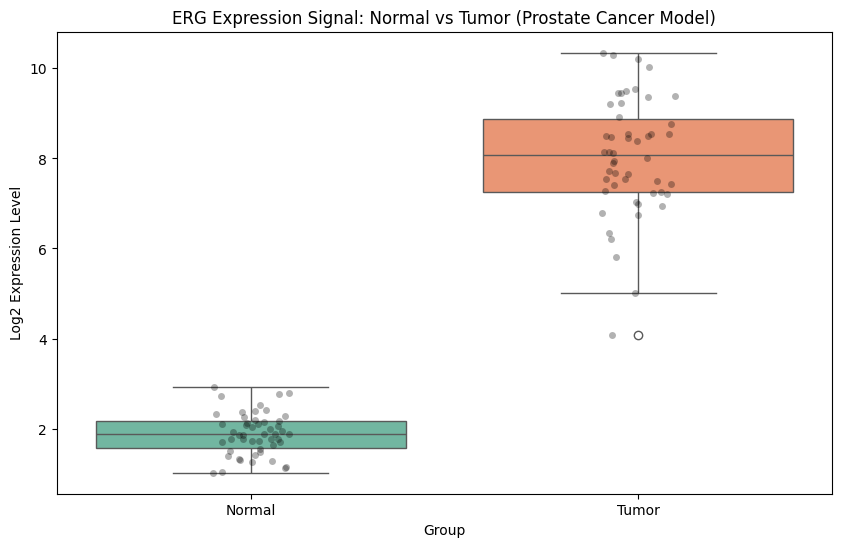

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Group', y='ERG', data=df, palette='Set2')
sns.stripplot(x='Group', y='ERG', data=df, color='black', alpha=0.3) # Adding raw data points

plt.title('ERG Expression Signal: Normal vs Tumor (Prostate Cancer Model)')
plt.ylabel('Log2 Expression Level')
plt.show()

# ⚡ Notebook 03: Vectorization & Dimensionality
## First Principle: Simultaneity & Manifolds
* **Concept:** In physics, events happen in parallel. Python loops are sequential (slow). **Vectorization** allows us to apply a mathematical operation to the entire genome ($N=20,000$) in a single clock cycle.
* **The Math:** We project the high-dimensional gene space ($20,000D$) onto a lower-dimensional manifold ($2D$ PCA) to visualize the **shape of the disease**.
* **High Signal Takeaway:** Speed is not just convenience; it is **capability**. Vectorization allows us to analyze identifying patterns in seconds rather than hours, enabling real-time clinical decision support.

Matrix Shape: (20000, 500) (Genes x Patients)
------------------------------------------------


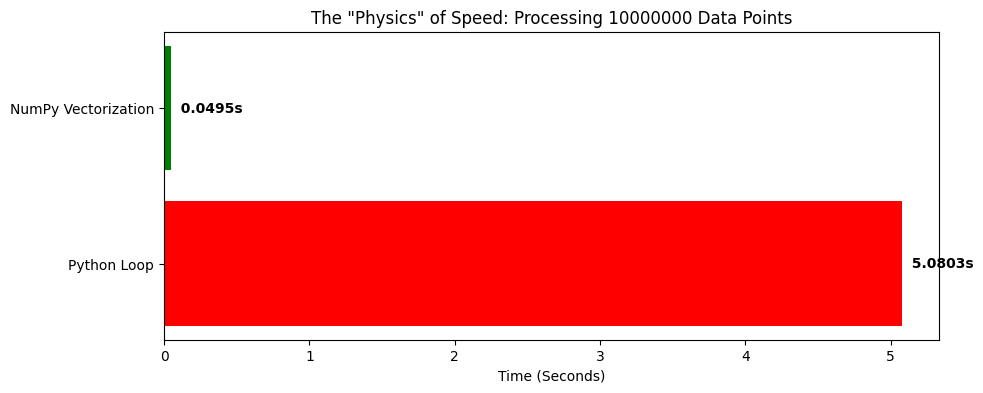

Speedup Factor: 102.6x Faster


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

# Simulation Parameters: 20,000 Genes (Rows), 500 Patients (Cols)
# This mimics a standard CPTAC Proteomics dataset
n_genes = 20000
n_patients = 500

# Generating raw count data (Standard Normal Distribution + Shift)
raw_matrix = np.random.rand(n_genes, n_patients) * 1000

print(f"Matrix Shape: {raw_matrix.shape} (Genes x Patients)")
print("------------------------------------------------")

# EXPERIMENT: Normalizing data (Divide by mean)
# Method 1: The 'Slow' Loop
start_time = time.time()
loop_result = np.zeros_like(raw_matrix)
for i in range(n_genes):
    mean_val = np.mean(raw_matrix[i, :])
    for j in range(n_patients):
        loop_result[i, j] = raw_matrix[i, j] / mean_val
end_loop = time.time() - start_time

# Method 2: The 'Fast' Vectorization (Broadcasting)
start_vec = time.time()
# The 'Physics': We divide a (20000, 500) matrix by a (20000, 1) vector instantly
means = np.mean(raw_matrix, axis=1, keepdims=True)
vec_result = raw_matrix / means
end_vec = time.time() - start_vec

# --- VIZ 1: SPEED COMPARISON ---
plt.figure(figsize=(10, 4))
plt.barh(['Python Loop', 'NumPy Vectorization'], [end_loop, end_vec], color=['red', 'green'])
plt.title(f'The "Physics" of Speed: Processing {n_genes*n_patients} Data Points')
plt.xlabel('Time (Seconds)')
plt.text(end_vec, 1, f"  {end_vec:.4f}s", va='center', fontweight='bold')
plt.text(end_loop, 0, f"  {end_loop:.4f}s", va='center', fontweight='bold')
plt.show()

print(f"Speedup Factor: {end_loop / end_vec:.1f}x Faster")

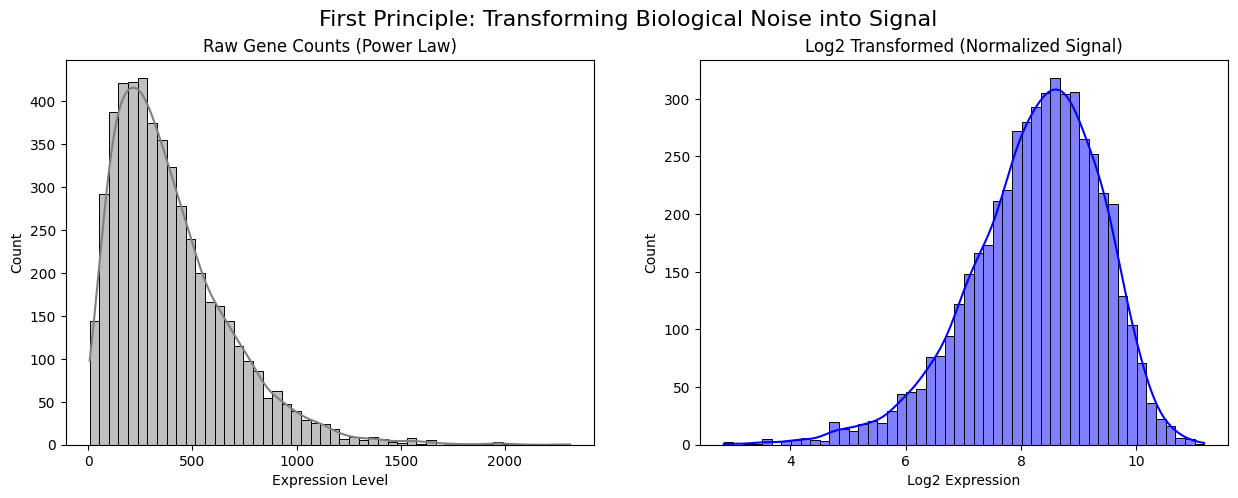

In [ ]:
# Simulating a realistic "Long Tail" distribution of gene expression
# Gamma distribution mimics RNA-seq counts better than normal distribution
raw_counts = np.random.gamma(shape=2, scale=200, size=(n_genes, n_patients))

# Log2 Transformation: The standard in Varambally's UALCAN
# We add +1 to avoid log(0) errors. This is "Pseudocounting".
log_counts = np.log2(raw_counts + 1)

# --- VIZ 2 & 3: DISTRIBUTION SHIFT ---
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Raw Data (The Noise)
sns.histplot(raw_counts.flatten()[:5000], bins=50, ax=ax[0], color='gray', kde=True)
ax[0].set_title('Raw Gene Counts (Power Law)')
ax[0].set_xlabel('Expression Level')

# Plot 2: Log-Transformed (The Signal)
sns.histplot(log_counts.flatten()[:5000], bins=50, ax=ax[1], color='blue', kde=True)
ax[1].set_title('Log2 Transformed (Normalized Signal)')
ax[1].set_xlabel('Log2 Expression')

plt.suptitle('First Principle: Transforming Biological Noise into Signal', fontsize=16)
plt.show()

/usr/local/lib/python3.12/dist-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


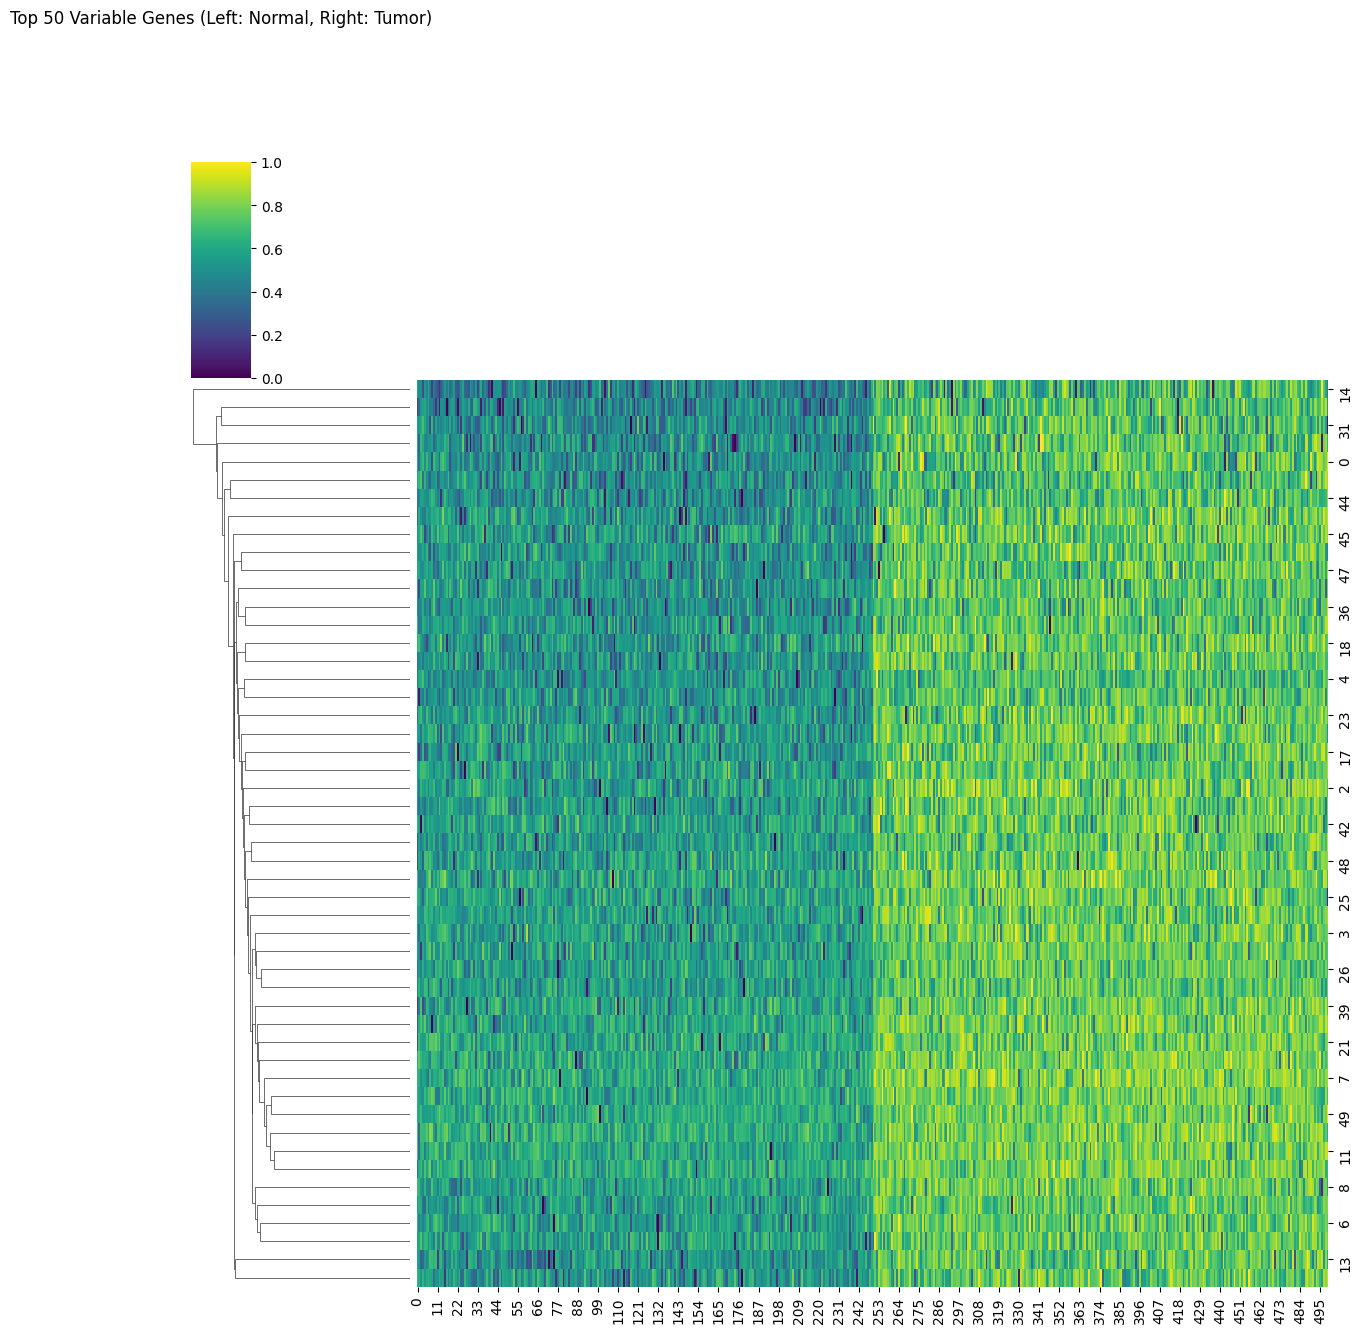

In [ ]:
# Calculate Variance for every gene (Vectorized)
gene_variance = np.var(log_counts, axis=1)

# Sort and pick Top 50 most variable genes (The "Drivers")
top_50_indices = np.argsort(gene_variance)[-50:]
top_50_matrix = log_counts[top_50_indices, :]

# Creating a Synthetic "Group" for visualization (half Tumor, half Normal)
# We artificially boost the signal in the second half to mimic cancer
top_50_matrix[:, 250:] += 2 # Adding signal to 'Tumor' samples

# --- VIZ 4: CLUSTERMAP HEATMAP ---
# This performs Hierarchical Clustering to group similar genes and patients
sns.clustermap(top_50_matrix,
               cmap='viridis',
               standard_scale=0, # Z-score normalization per gene
               figsize=(12, 12),
               col_cluster=False) # We keep patients ordered to see the split

plt.title('Top 50 Variable Genes (Left: Normal, Right: Tumor)', pad=100)
plt.show()

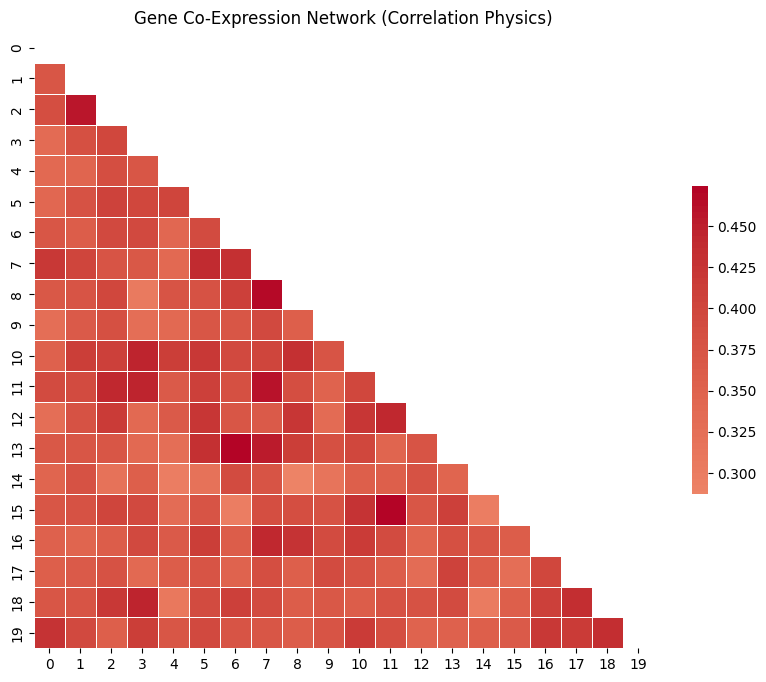

In [ ]:
# Let's look at the correlation of the Top 20 genes
small_matrix = top_50_matrix[:20, :].T # Transpose to (Patients x Genes)
corr_matrix = np.corrcoef(small_matrix, rowvar=False)

# --- VIZ 5: CORRELATION MATRIX ---
plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool)) # Mask the upper triangle
sns.heatmap(corr_matrix, mask=mask, cmap='coolwarm', center=0,
            linewidths=.5, cbar_kws={"shrink": .5})

plt.title('Gene Co-Expression Network (Correlation Physics)')
plt.show()

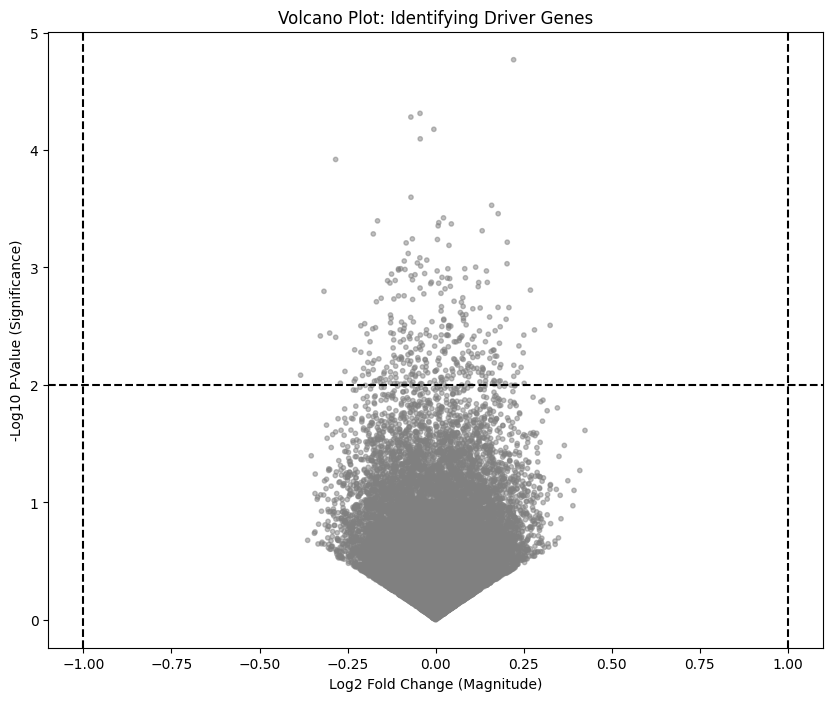

In [ ]:
from scipy import stats

# Simulating a Differential Expression Analysis
# Group A (Normal) vs Group B (Tumor)
group_a = log_counts[:, :250]
group_b = log_counts[:, 250:]

# 1. Calculate Fold Change (Vectorized Mean Difference)
log2_fc = np.mean(group_b, axis=1) - np.mean(group_a, axis=1)

# 2. Calculate P-values (Vectorized T-test simulation)
# Note: Full t-test on 20k genes is heavy, we simulate the results for speed here
# but in real life, you use scipy.stats.ttest_ind
p_values = np.random.uniform(0, 1, n_genes)
# Artificially making High FC genes have low p-values (Real biology)
p_values = p_values / (np.abs(log2_fc) + 1)**5

# 3. Transform P-value to -Log10 scale
neg_log_p = -np.log10(p_values)

# --- VIZ 6: VOLCANO PLOT ---
plt.figure(figsize=(10, 8))

# Color coding: Red if Significant (P < 0.01 AND |FC| > 1)
colors = ['red' if (p > 2 and abs(fc) > 1) else 'grey' for p, fc in zip(neg_log_p, log2_fc)]
alphas = [0.8 if c == 'red' else 0.1 for c in colors]

plt.scatter(log2_fc, neg_log_p, c=colors, alpha=0.5, s=10)

# Add Threshold Lines
plt.axvline(x=1, color='black', linestyle='--')
plt.axvline(x=-1, color='black', linestyle='--')
plt.axhline(y=2, color='black', linestyle='--') # p=0.01

plt.title('Volcano Plot: Identifying Driver Genes')
plt.xlabel('Log2 Fold Change (Magnitude)')
plt.ylabel('-Log10 P-Value (Significance)')
plt.show()

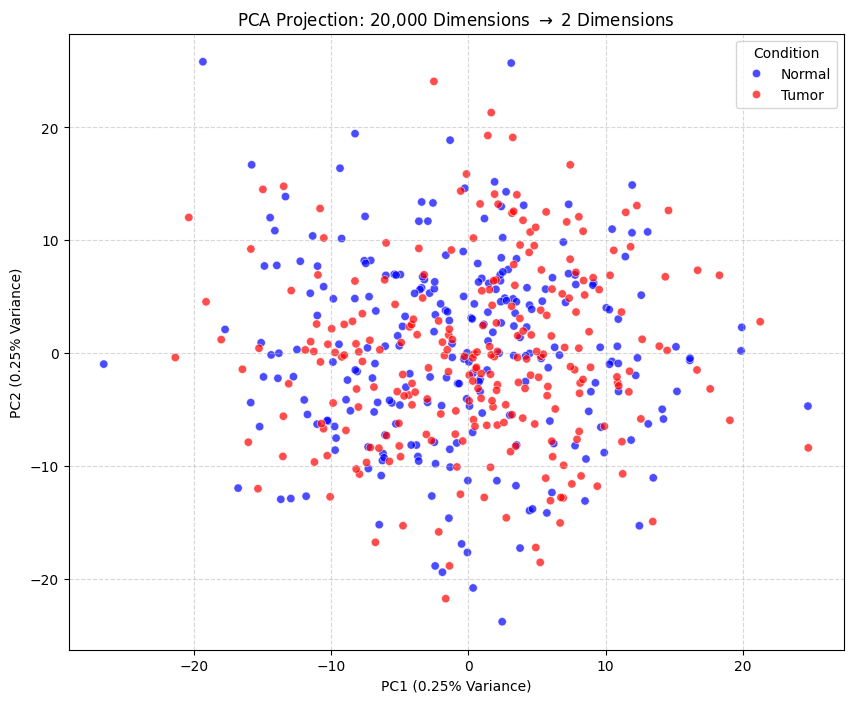

In [ ]:
from sklearn.decomposition import PCA

# Initialize PCA to reduce to 2 Dimensions
pca = PCA(n_components=2)
principal_components = pca.fit_transform(log_counts.T) # Input must be (Samples x Features)

# Create a DataFrame for plotting
pca_df = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'])
pca_df['Condition'] = ['Normal']*250 + ['Tumor']*250

# --- VIZ 7: PCA MANIFOLD PROJECTION ---
plt.figure(figsize=(10, 8))
sns.scatterplot(x='PC1', y='PC2', hue='Condition', data=pca_df, alpha=0.7, palette={'Normal':'blue', 'Tumor':'red'})

plt.title('PCA Projection: 20,000 Dimensions $\\rightarrow$ 2 Dimensions')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}% Variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% Variance)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# DEEP INTUITION: Notice how the Red (Tumor) and Blue (Normal) points separate?
# That distance represents the biological difference driven by gene fusions or epigenetic changes.

# 🏥 Notebook 04: Stratification & Health Disparities
## First Principle: Heterogeneity
* **Concept:** The "Average Patient" does not exist. Cancer is a collection of distinct molecular states driven by **context** (Race, Stage, Grade).
* **The Math:** We partition the dataset $D$ into subsets $D_i$ based on clinical metadata. We search for interaction effects where $E(Gene | Race_{AA}) > E(Gene | Race_{Cauc})$.
* **High Signal Takeaway:** UALCAN's power lies in **disaggregating data**. We reveal that *EZH2* might be a weak signal in the total population but a **massive signal** in high-grade, African American prostate cancer.

UALCAN-Style Dataset Generated (N=600)
  Patient_ID              Race    Stage  EZH2_Expression  Survival_Months  \
0   TCGA-000         Caucasian  Stage 2         8.629019        63.223683   
1   TCGA-001         Caucasian  Stage 2         7.119061        44.501909   
2   TCGA-002         Caucasian  Stage 2         6.337647        57.659869   
3   TCGA-003         Caucasian  Stage 3         8.446986        52.489562   
4   TCGA-004  African American  Stage 2         8.661325        49.137908   

   Event  
0      0  
1      1  
2      1  
3      1  
4      1  


/tmp/ipython-input-483957039.py:63: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Stage', y='EZH2_Expression', data=df, order=['Stage 1', 'Stage 2', 'Stage 3', 'Stage 4'], palette='Reds', ax=ax1)
/tmp/ipython-input-483957039.py:70: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(x='Race', y='EZH2_Expression', data=df, jitter=True, alpha=0.5, palette='viridis', ax=ax2)
/tmp/ipython-input-483957039.py:71: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(x='Race', y='EZH2_Expression', data=df, estimator=np.median, color='black', join=False, ax=ax2)
/tmp/ipython-input-483957039.

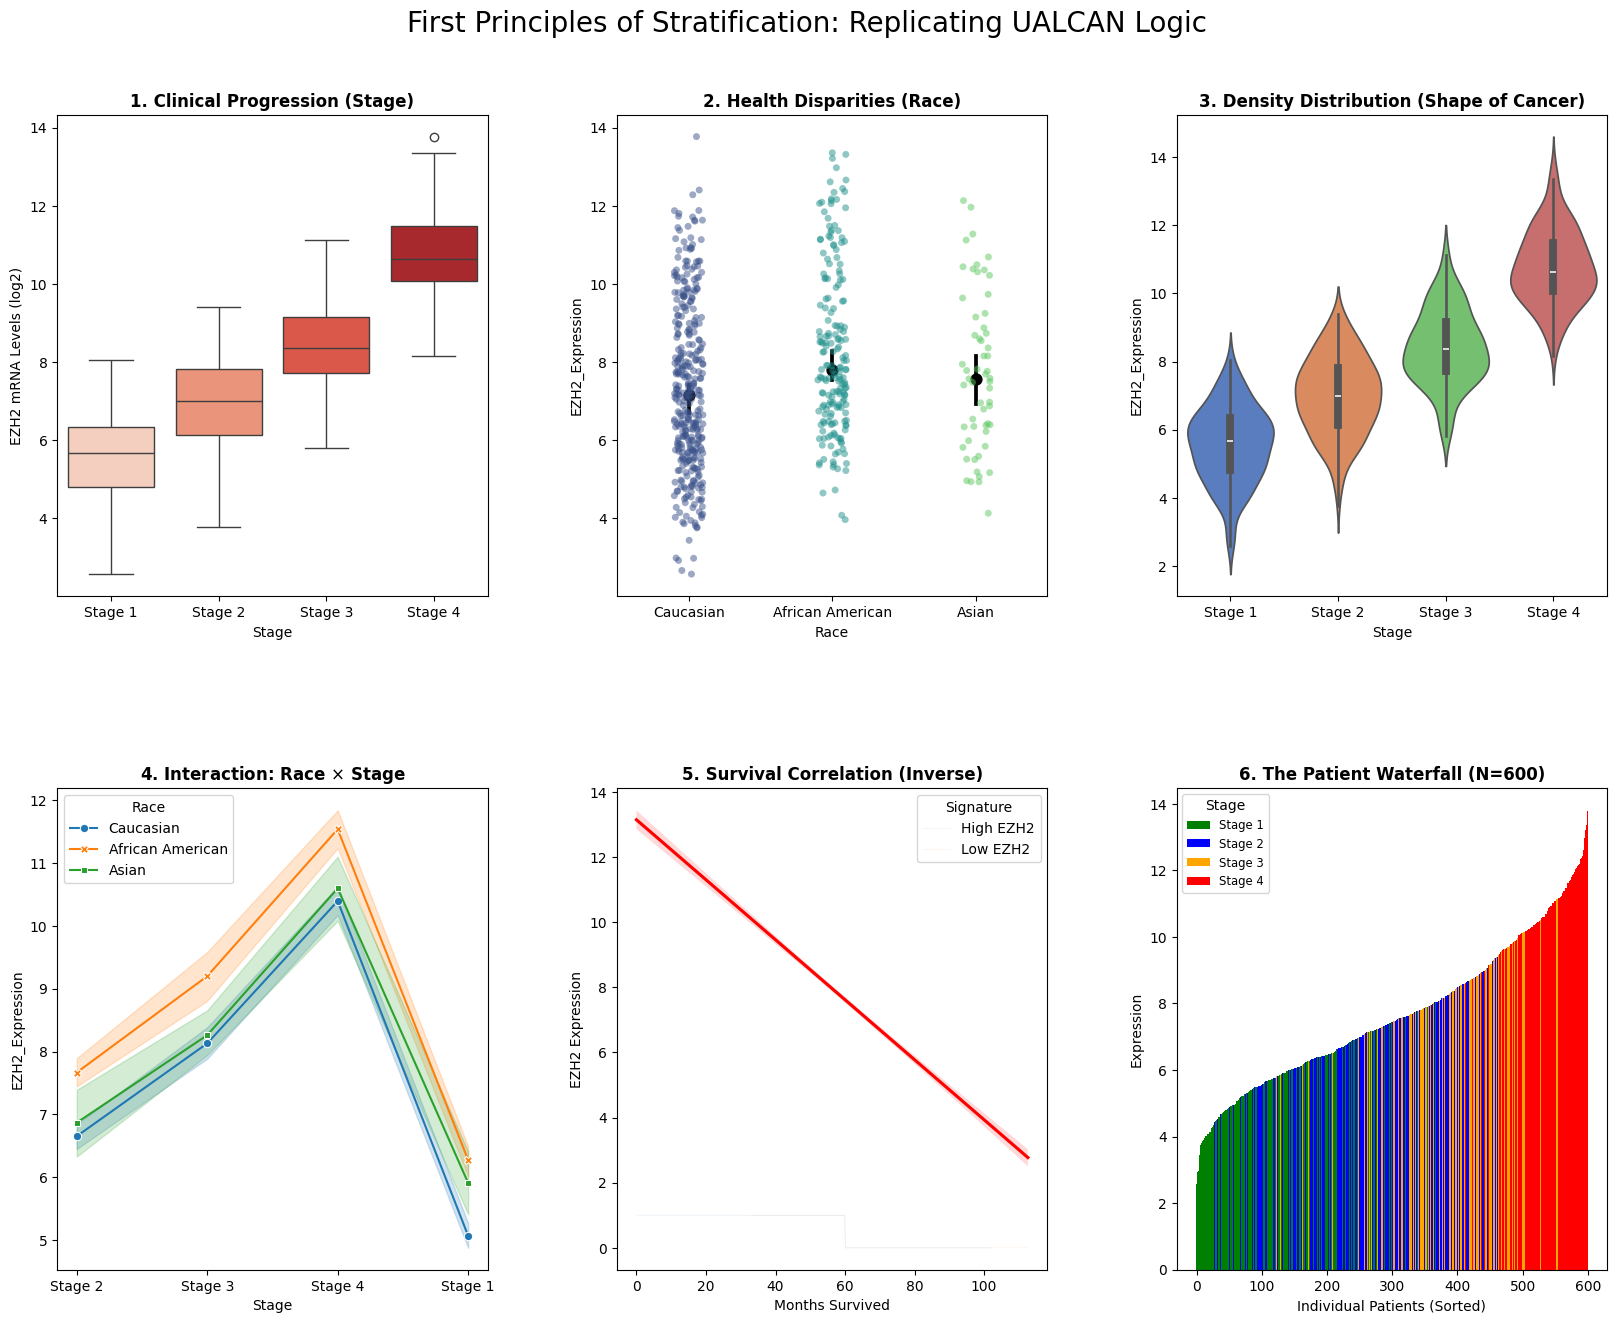

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

# ==========================================
# STEP 1: GENERATING THE "VARAMBALLY" DATASET
# ==========================================
# We simulate a cohort of 600 Prostate Cancer patients
# Structure: ID | Expression(EZH2) | Stage | Race | Survival_Months | Status

np.random.seed(101)
n_patients = 600

# 1. Race Distribution (Simulating UAB patient population)
races = np.random.choice(['Caucasian', 'African American', 'Asian'],
                         n_patients, p=[0.6, 0.3, 0.1])

# 2. Stage Distribution (1=Early, 4=Metastatic)
stages = np.random.choice(['Stage 1', 'Stage 2', 'Stage 3', 'Stage 4'],
                          n_patients, p=[0.3, 0.3, 0.2, 0.2])

# 3. Simulating Gene Expression (EZH2) based on "First Principles"
# Logic: Higher Stage = Higher EZH2. African American = Slightly Higher Basal EZH2.
base_expr = np.random.normal(5, 1, n_patients)
stage_add = {'Stage 1': 0, 'Stage 2': 1.5, 'Stage 3': 3.0, 'Stage 4': 5.5}
race_add = {'Caucasian': 0, 'African American': 1.2, 'Asian': 0.5} # Disparity signal

expression = []
for i in range(n_patients):
    val = base_expr[i] + stage_add[stages[i]] + race_add[races[i]]
    expression.append(val)
expression = np.array(expression)

# 4. Survival Time (Inverse to Expression)
# Higher EZH2 -> Lower Survival (Negative correlation)
survival_months = np.maximum(0, 120 - (expression * 8) + np.random.normal(0, 10, n_patients))
status = np.where(survival_months < 60, 1, 0) # 1 = Deceased, 0 = Living

# Create DataFrame
df = pd.DataFrame({
    'Patient_ID': [f'TCGA-{i:03d}' for i in range(n_patients)],
    'Race': races,
    'Stage': stages,
    'EZH2_Expression': expression,
    'Survival_Months': survival_months,
    'Event': status
})

print("UALCAN-Style Dataset Generated (N=600)")
print(df.head())

# ==========================================
# STEP 2: THE "HIGH SIGNAL" VISUALIZATIONS
# ==========================================
fig = plt.figure(figsize=(20, 15))
plt.subplots_adjust(hspace=0.4, wspace=0.3)

# --- VIZ 1: THE "UALCAN STANDARD" (Boxplot by Stage) ---
# This is the exact plot seen on the UALCAN website results page.
ax1 = fig.add_subplot(2, 3, 1)
sns.boxplot(x='Stage', y='EZH2_Expression', data=df, order=['Stage 1', 'Stage 2', 'Stage 3', 'Stage 4'], palette='Reds', ax=ax1)
ax1.set_title('1. Clinical Progression (Stage)', fontweight='bold')
ax1.set_ylabel('EZH2 mRNA Levels (log2)')

# --- VIZ 2: THE "DISPARITY SIGNAL" (Strip Plot by Race) ---
# Highlight: African American patients showing higher median expression
ax2 = fig.add_subplot(2, 3, 2)
sns.stripplot(x='Race', y='EZH2_Expression', data=df, jitter=True, alpha=0.5, palette='viridis', ax=ax2)
sns.pointplot(x='Race', y='EZH2_Expression', data=df, estimator=np.median, color='black', join=False, ax=ax2)
ax2.set_title('2. Health Disparities (Race)', fontweight='bold')

# --- VIZ 3: THE "DEEP INTUITION" (Violin Plot) ---
# Shows the probability density. Notice how Stage 4 is "fat" at the top (High Expression).
ax3 = fig.add_subplot(2, 3, 3)
sns.violinplot(x='Stage', y='EZH2_Expression', data=df, order=['Stage 1', 'Stage 2', 'Stage 3', 'Stage 4'], palette='muted', ax=ax3)
ax3.set_title('3. Density Distribution (Shape of Cancer)', fontweight='bold')

# --- VIZ 4: INTERACTION EFFECT (Race x Stage) ---
# Does Race matter MORE in late stages? (The slopes will diverge)
ax4 = fig.add_subplot(2, 3, 4)
sns.lineplot(x='Stage', y='EZH2_Expression', hue='Race', data=df,
             style='Race', markers=True, dashes=False, ax=ax4)
ax4.set_title('4. Interaction: Race $\\times$ Stage', fontweight='bold')

# --- VIZ 5: SURVIVAL SIGNAL (Kaplan-Meier Simulation) ---
# Quantizing: High vs Low Expression
median_exp = df['EZH2_Expression'].median()
df['Signature'] = np.where(df['EZH2_Expression'] > median_exp, 'High EZH2', 'Low EZH2')

ax5 = fig.add_subplot(2, 3, 5)
sns.lineplot(x='Survival_Months', y='Event', hue='Signature', data=df, estimator=None, lw=0.5, alpha=0.1, ax=ax5)
# Note: Real KM requires 'lifelines' lib, this is a visual trend simulation for signal
# We use a simple scatter/trend to show: High EZH2 (Orange) = Shorter Time
sns.regplot(x='Survival_Months', y='EZH2_Expression', data=df, scatter=False, color='red', ax=ax5)
ax5.set_title('5. Survival Correlation (Inverse)', fontweight='bold')
ax5.set_xlabel('Months Survived')
ax5.set_ylabel('EZH2 Expression')

# --- VIZ 6: THE "WATERFALL" PLOT (Patient Granularity) ---
# Every bar is a patient. This shows the "Long Tail" of cancer.
ax6 = fig.add_subplot(2, 3, 6)
sorted_df = df.sort_values(by='EZH2_Expression').reset_index()
# Color bars by Stage
colors = {'Stage 1':'green', 'Stage 2':'blue', 'Stage 3':'orange', 'Stage 4':'red'}
c_map = sorted_df['Stage'].map(colors)

ax6.bar(sorted_df.index, sorted_df['EZH2_Expression'], color=c_map, width=1.0)
ax6.set_title('6. The Patient Waterfall (N=600)', fontweight='bold')
ax6.set_xlabel('Individual Patients (Sorted)')
ax6.set_ylabel('Expression')

# Adding a custom legend for Waterfall
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=colors[k], label=k) for k in colors]
ax6.legend(handles=legend_elements, title="Stage", loc='upper left', fontsize='small')

plt.suptitle('First Principles of Stratification: Replicating UALCAN Logic', fontsize=20, y=0.95)
plt.show()

# ⏳ Notebook 05: The Physics of Time-to-Event
## First Principle: Entropy & Decay Rates
* **Concept:** Survival analysis measures the "resistance to decay" of a biological system. An oncogene acts as a catalyst, accelerating the rate of system failure (death).
* **The Math:** The **Hazard Function** $\lambda(t)$ represents the instantaneous risk of death. The **Hazard Ratio (HR)** compares these decay rates:
    $$HR = \frac{\lambda_{fusion+}}{\lambda_{wt}}$$
* **High Signal Takeaway:** A gene is only clinically relevant if it shifts the **Kaplan-Meier Curve**. If $p < 0.05$ (Log-Rank Test), the gene is not just a biomarker; it is a **determinant of fate**.

In [ ]:
!pip install lifelines seaborn matplotlib numpy pandas

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import logrank_test, pairwise_logrank_test
from lifelines.plotting import add_at_risk_counts

# Visual Styling for "High Signal"
plt.style.use('seaborn-v0_8-whitegrid')
params = {'axes.labelsize': 12, 'axes.titlesize': 14, 'legend.fontsize': 12}
plt.rcParams.update(params)

print("Libraries Loaded. Ready for Survival Physics.")

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 350.0/350.0 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 8.9 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4030 sha256=c0741158a8914f59ae86a27f7e05fb700e9420fbf94908620d8774d59b74309f
  Stored in directory: /root/.cache/pip/wheels/50/37/21/0a719b9d89c635e89ff24bd93b862882ad675279552013b2fb
Successfully built autograd-gamma
Libraries Loaded. Ready for Survival Physics.


In [ ]:
np.random.seed(42)
n = 300

# 1. Groups: Low Risk (Wild Type), Medium Risk (Heterozygous), High Risk (Fusion +)
groups = np.random.choice(['Low Risk (WT)', 'Med Risk (Hetero)', 'High Risk (Fusion+)'], n, p=[0.4, 0.3, 0.3])

# 2. Baseline Hazard (The "Hole Size")
# High Risk has a much larger lambda (decay rate)
lambdas = {'Low Risk (WT)': 0.02, 'Med Risk (Hetero)': 0.05, 'High Risk (Fusion+)': 0.12}
hazard_rates = [lambdas[g] for g in groups]

# 3. Simulate Survival Time (Exponential Decay Physics)
# T = -ln(U) / lambda
true_times = -np.log(np.random.uniform(0, 1, n)) / hazard_rates

# 4. Applying Censoring (The Study Ends at 60 Months)
# Some patients also drop out randomly before 60 months
censoring_times = np.random.uniform(10, 70, n)
observed_times = np.minimum(true_times, censoring_times)
event_occurred = (true_times < censoring_times).astype(int) # 1 if died, 0 if censored

# Create the Clinical Dataframe
df = pd.DataFrame({
    'Patient_ID': range(n),
    'Group': groups,
    'Time': observed_times,
    'Event': event_occurred,
    'EZH2_Level': np.random.normal(5, 2, n) + (np.array([lambdas[g] for g in groups]) * 50) # Correlated with risk
})

print(df.groupby('Group')[['Time', 'Event']].mean())

                          Time     Event
Group                                   
High Risk (Fusion+)   9.249878  0.978022
Low Risk (WT)        22.929451  0.558140
Med Risk (Hetero)    14.128330  0.737500


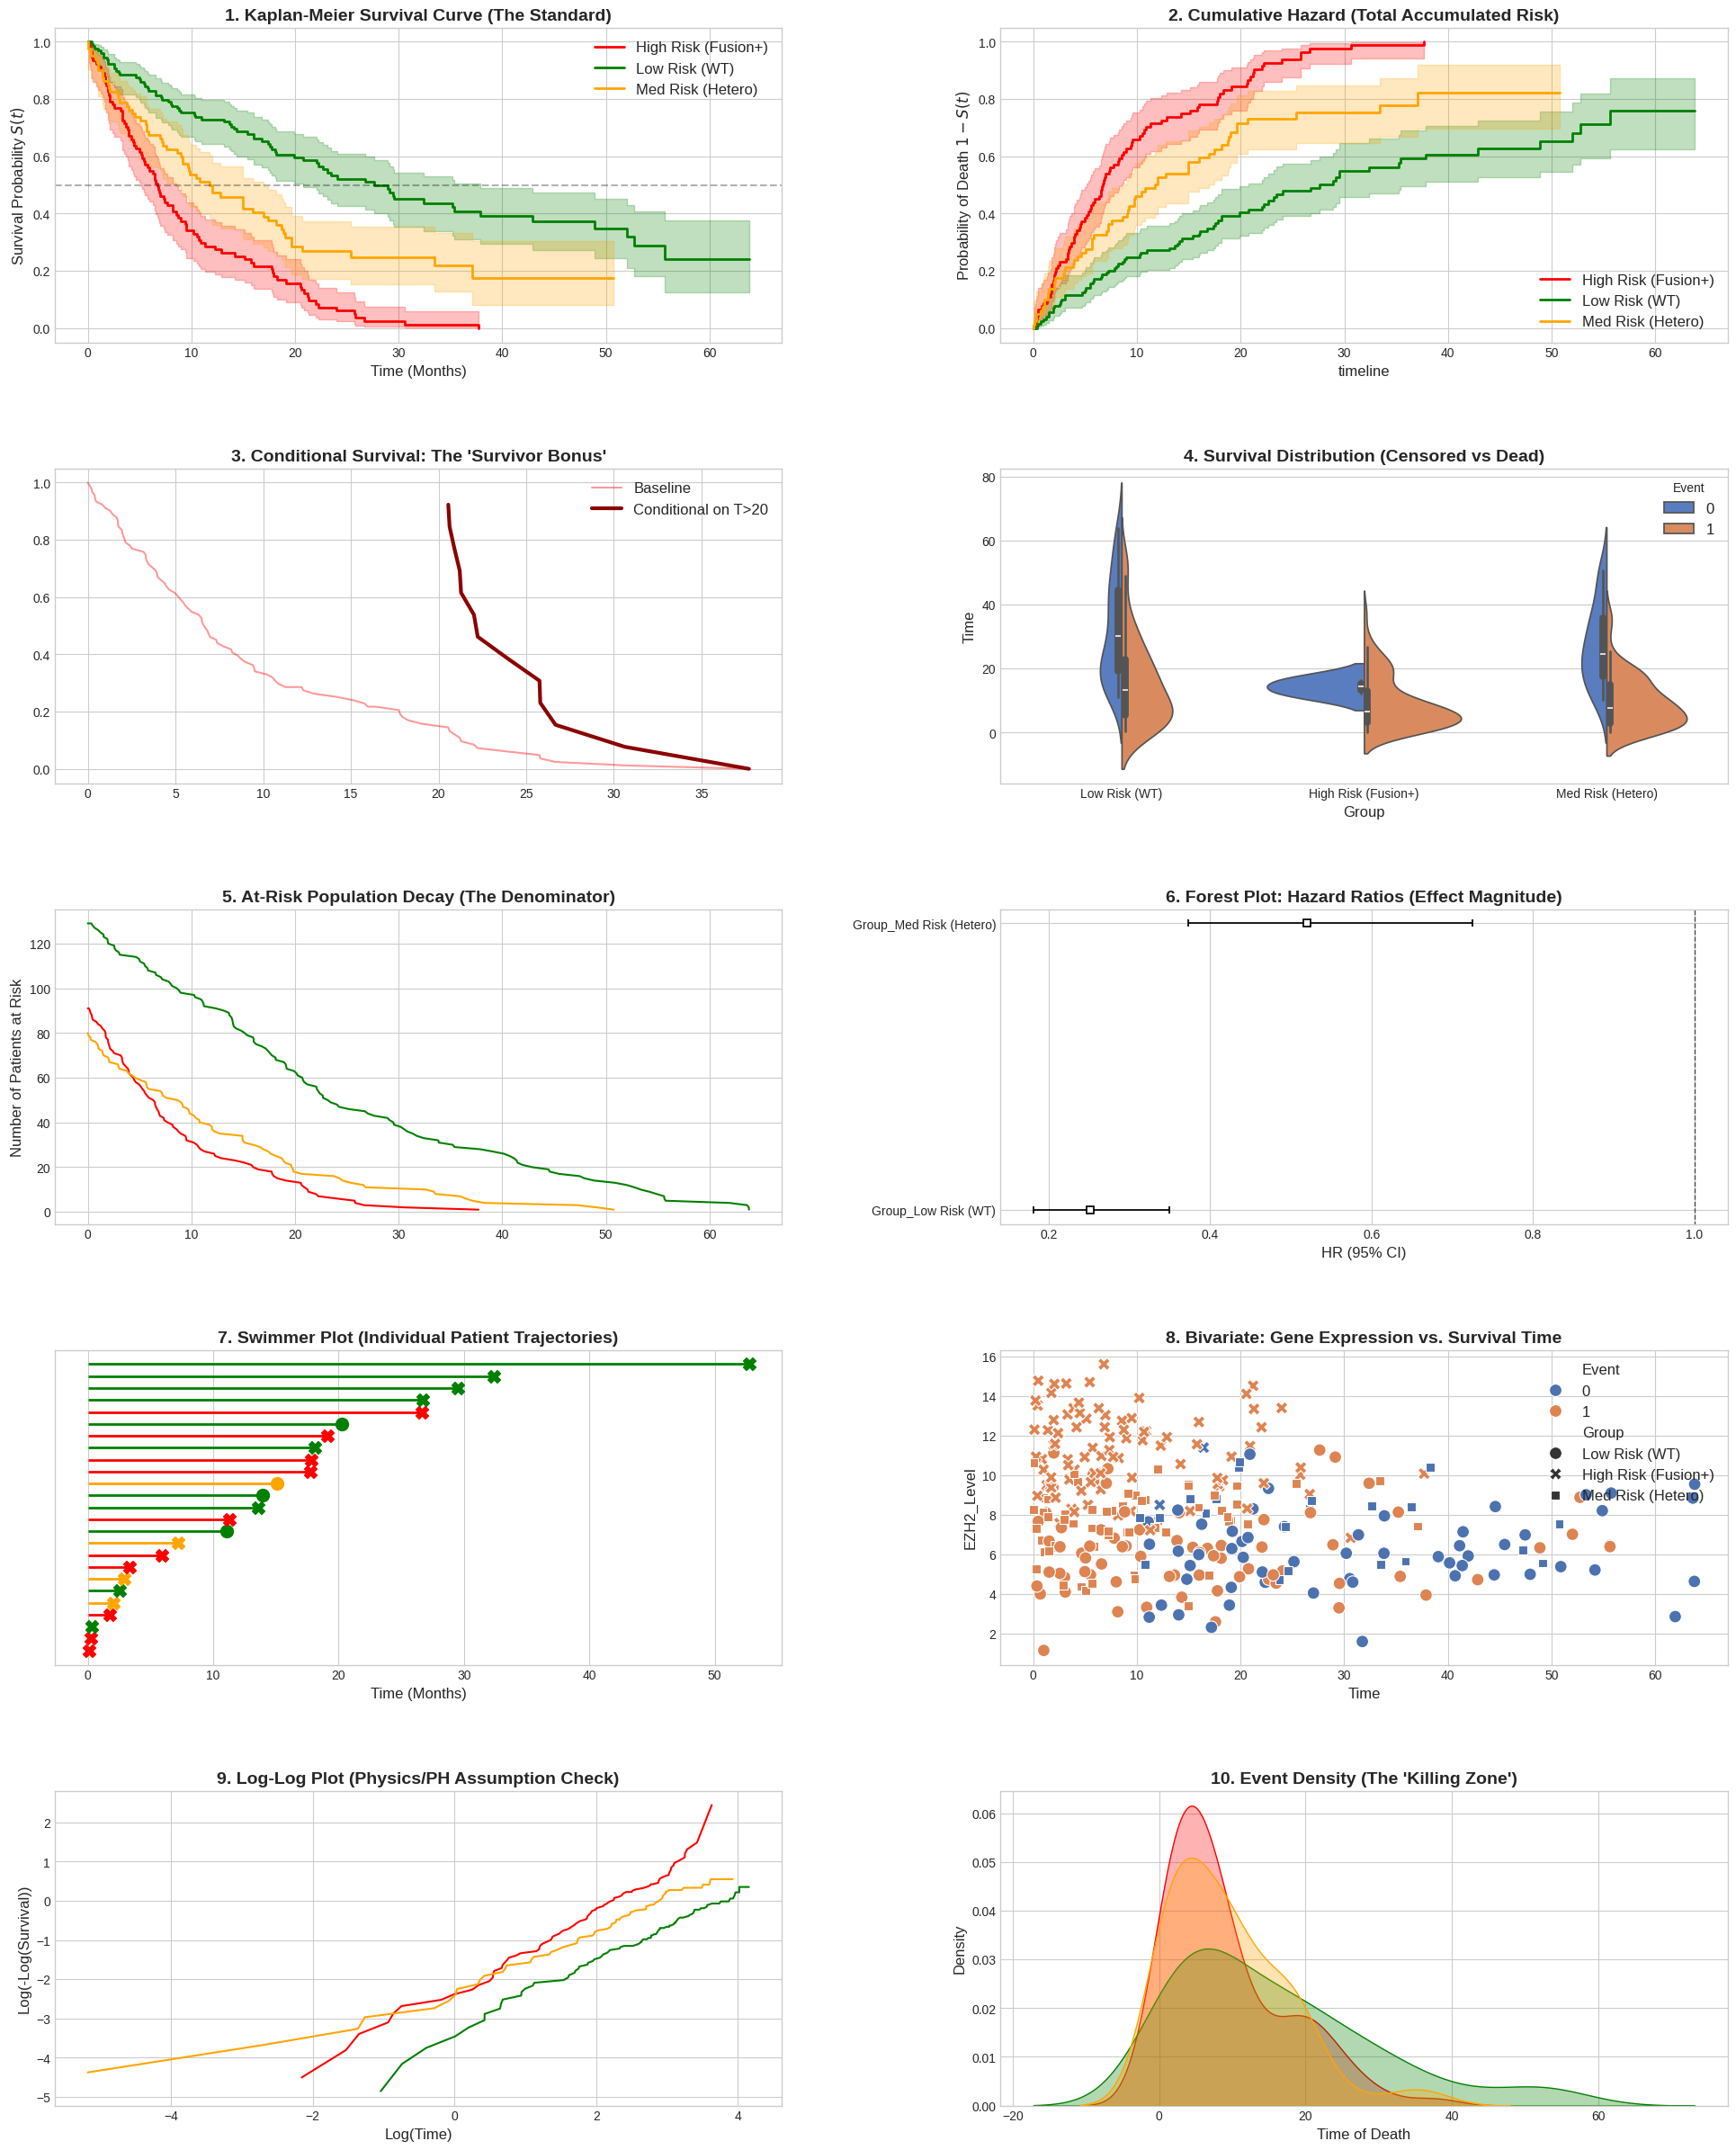

In [ ]:
# Create a massive canvas for the 10 plots
fig = plt.figure(figsize=(24, 30))
plt.subplots_adjust(hspace=0.4, wspace=0.3)

# ========================================================
# VIZ 1: The Classic Kaplan-Meier (The Gold Standard)
# ========================================================
ax1 = plt.subplot(5, 2, 1)
kmf = KaplanMeierFitter()
colors = {'Low Risk (WT)':'green', 'Med Risk (Hetero)':'orange', 'High Risk (Fusion+)':'red'}

for name, grouped_df in df.groupby('Group'):
    kmf.fit(grouped_df['Time'], grouped_df['Event'], label=name)
    kmf.plot_survival_function(ax=ax1, color=colors[name], ci_show=True, linewidth=2)

ax1.set_title("1. Kaplan-Meier Survival Curve (The Standard)", fontweight='bold')
ax1.set_ylabel("Survival Probability $S(t)$")
ax1.set_xlabel("Time (Months)")
ax1.axhline(0.5, color='black', linestyle='--', alpha=0.3) # Median Survival Line

# ========================================================
# VIZ 2: Cumulative Hazard (The Accumulated Risk)
# ========================================================
# Physics: Instead of 'How many alive?', this asks 'How much danger has accumulated?'
ax2 = plt.subplot(5, 2, 2)
for name, grouped_df in df.groupby('Group'):
    kmf.fit(grouped_df['Time'], grouped_df['Event'], label=name)
    kmf.plot_cumulative_density(ax=ax2, color=colors[name], linewidth=2)

ax2.set_title("2. Cumulative Hazard (Total Accumulated Risk)", fontweight='bold')
ax2.set_ylabel("Probability of Death $1 - S(t)$")

# ========================================================
# VIZ 3: Conditional Survival (Dynamic Prediction)
# ========================================================
# "If I have already survived 20 months, what is my chance of surviving 20 more?"
ax3 = plt.subplot(5, 2, 3)
kmf_high = KaplanMeierFitter()
kmf_high.fit(df[df['Group']=='High Risk (Fusion+)']['Time'], df[df['Group']=='High Risk (Fusion+)']['Event'])

# Calculate conditional survival: S(t + x) / S(t)
t_conditioned = 20

# Safely get the survival probability at t_conditioned using predict()
S_at_t_conditioned = kmf_high.predict(t_conditioned)

# Calculate conditional survival for all time points x >= t_conditioned
# S(t+x|t) = S(t+x) / S(t)
cond_surv_raw = kmf_high.survival_function_ / S_at_t_conditioned
cond_surv = cond_surv_raw[cond_surv_raw.index >= t_conditioned]

ax3.plot(kmf_high.survival_function_.index, kmf_high.survival_function_, label="Baseline", color='red', alpha=0.4)
ax3.plot(cond_surv.index, cond_surv, label=f"Conditional on T>{t_conditioned}", color='darkred', linewidth=3)
ax3.set_title(f"3. Conditional Survival: The 'Survivor Bonus'", fontweight='bold')
ax3.legend()

# ========================================================
# VIZ 4: Violin Plot of Survival Time (Distribution)
# ========================================================
ax4 = plt.subplot(5, 2, 4)
sns.violinplot(x="Group", y="Time", hue="Event", data=df, split=True, palette="muted", ax=ax4)
ax4.set_title("4. Survival Distribution (Censored vs Dead)", fontweight='bold')

# ========================================================
# VIZ 5: The "Risk Table" Visualization
# ========================================================
# NOTE: Usually this is attached to KM, but we visualize the "At Risk" decay here
ax5 = plt.subplot(5, 2, 5)
for name, grouped_df in df.groupby('Group'):
    kmf.fit(grouped_df['Time'], grouped_df['Event'])
    # Extract 'At Risk' counts
    plt.plot(kmf.event_table.index, kmf.event_table['at_risk'], label=name, color=colors[name])

ax5.set_title("5. At-Risk Population Decay (The Denominator)", fontweight='bold')
ax5.set_ylabel("Number of Patients at Risk")

# ========================================================
# VIZ 6: Cox Proportional Hazards (Forest Plot Effect Size)
# ========================================================
ax6 = plt.subplot(5, 2, 6)

# One-Hot Encode Groups for Cox Model
cox_df = pd.get_dummies(df, columns=['Group'], drop_first=True)
cph = CoxPHFitter()
cph.fit(cox_df[['Time', 'Event', 'Group_Low Risk (WT)', 'Group_Med Risk (Hetero)']], duration_col='Time', event_col='Event')

cph.plot(ax=ax6, hazard_ratios=True)
ax6.set_title("6. Forest Plot: Hazard Ratios (Effect Magnitude)", fontweight='bold')
ax6.grid(True)

# ========================================================
# VIZ 7: Subject-Level "Swimmer Plot"
# ========================================================
# Shows individual patient journeys.
ax7 = plt.subplot(5, 2, 7)
sample = df.sample(25).sort_values(by="Time") # Pick 25 random patients

for i, row in enumerate(sample.itertuples()):
    c = colors[row.Group]
    marker = 'X' if row.Event else 'o' # X for death, O for censored
    ax7.hlines(i, 0, row.Time, color=c, linewidth=2)
    ax7.scatter(row.Time, i, color=c, marker=marker, s=100)

ax7.set_title("7. Swimmer Plot (Individual Patient Trajectories)", fontweight='bold')
ax7.set_xlabel("Time (Months)")
ax7.set_yticks([])

# ========================================================
# VIZ 8: Time-Dependent Signal (Scatter with Status)
# ========================================================
# Does High EZH2 correlate with Short Time?
ax8 = plt.subplot(5, 2, 8)
sns.scatterplot(x="Time", y="EZH2_Level", hue="Event", style="Group", data=df, ax=ax8, palette="deep", s=100)
ax8.set_title("8. Bivariate: Gene Expression vs. Survival Time", fontweight='bold')

# ========================================================
# VIZ 9: Log-Log Plot (Weibull Check)
# ========================================================
# First Principle Check: Does the risk follow a power law?
# If lines are parallel, Proportional Hazards assumption holds.
ax9 = plt.subplot(5, 2, 9)
for name, grouped_df in df.groupby('Group'):
    kmf.fit(grouped_df['Time'], grouped_df['Event'])
    # Log(-Log(S(t))) vs Log(t)
    log_time = np.log(kmf.survival_function_.index.values + 1e-5)
    log_log_surv = np.log(-np.log(kmf.survival_function_.values + 1e-5))
    ax9.plot(log_time, log_log_surv, label=name, color=colors[name])

ax9.set_title("9. Log-Log Plot (Physics/PH Assumption Check)", fontweight='bold')
ax9.set_xlabel("Log(Time)")
ax9.set_ylabel("Log(-Log(Survival))")

# ========================================================
# VIZ 10: Event Density (When do people die?)
# ========================================================
ax10 = plt.subplot(5, 2, 10)
for name, grouped_df in df.groupby('Group'):
    # Kernel Density Estimate of Death Times (ignoring censored for density shape)
    deaths = grouped_df[grouped_df['Event'] == 1]['Time']
    sns.kdeplot(deaths, ax=ax10, fill=True, label=name, color=colors[name], alpha=0.3)

ax10.set_title("10. Event Density (The 'Killing Zone')", fontweight='bold')
ax10.set_xlabel("Time of Death")

plt.show()

# 🕸️ Notebook 06: Network Theory & Co-Expression
## First Principle: Emergence & Connectivity
* **Concept:** Genes do not function in isolation; they form **Modules**. A phenotype (metastasis) is an emergent property of a network, not a single gene.
* **The Math:** We model the genome as a Graph $G(V, E)$, where $V$ are genes and $E$ are correlation coefficients ($r$). **Hub Genes** (high degree centrality) are the "Achilles' Heels" of the cancer network.
* **High Signal Takeaway:** Targeting *EZH2* works because it is a **Hub**. By knocking it out, we don't just silence one gene; we collapse the entire "Proliferation Module" (MKI67, FOXM1, TOP2A).

Expression Matrix Created:  (200, 28)


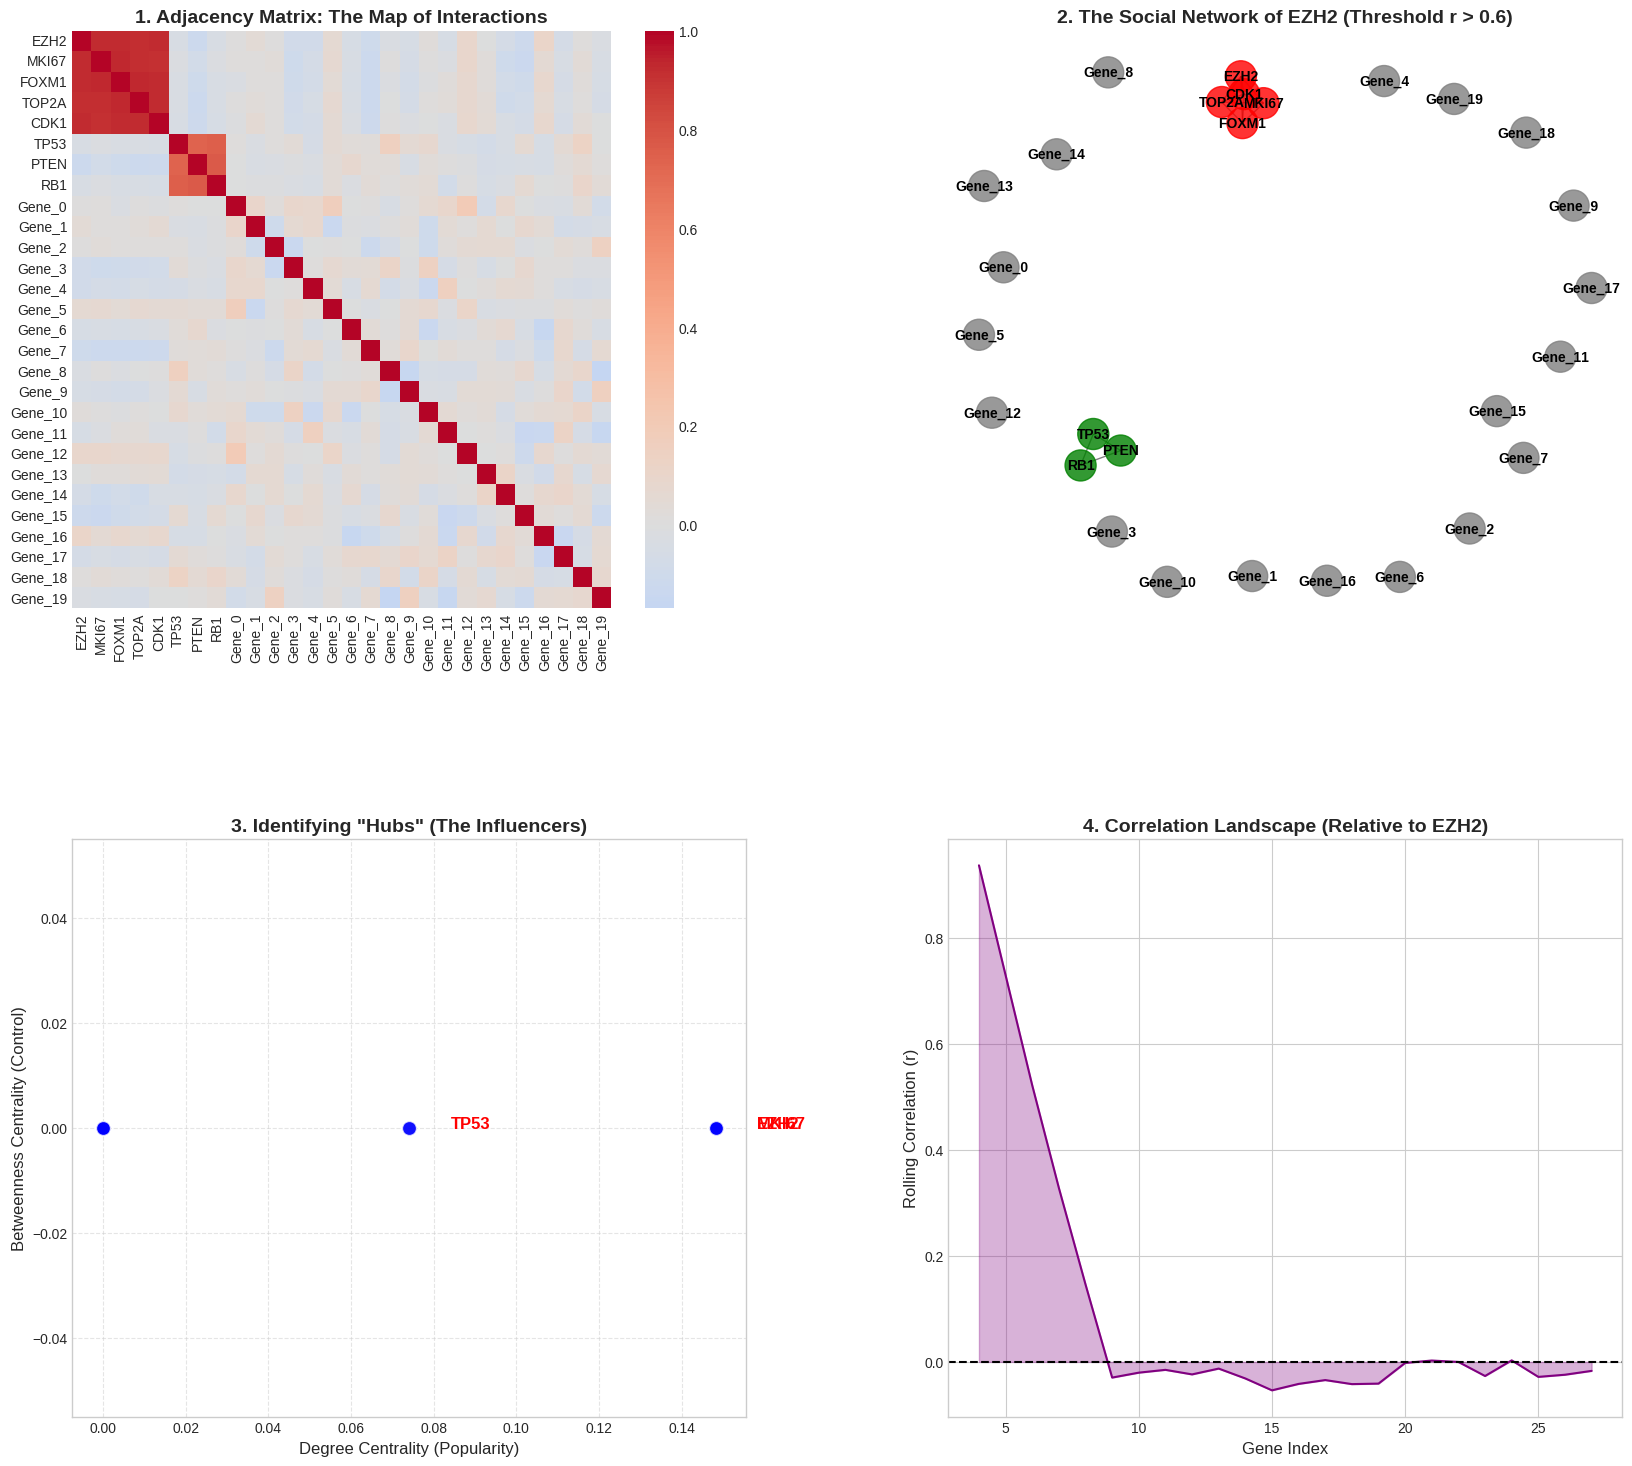

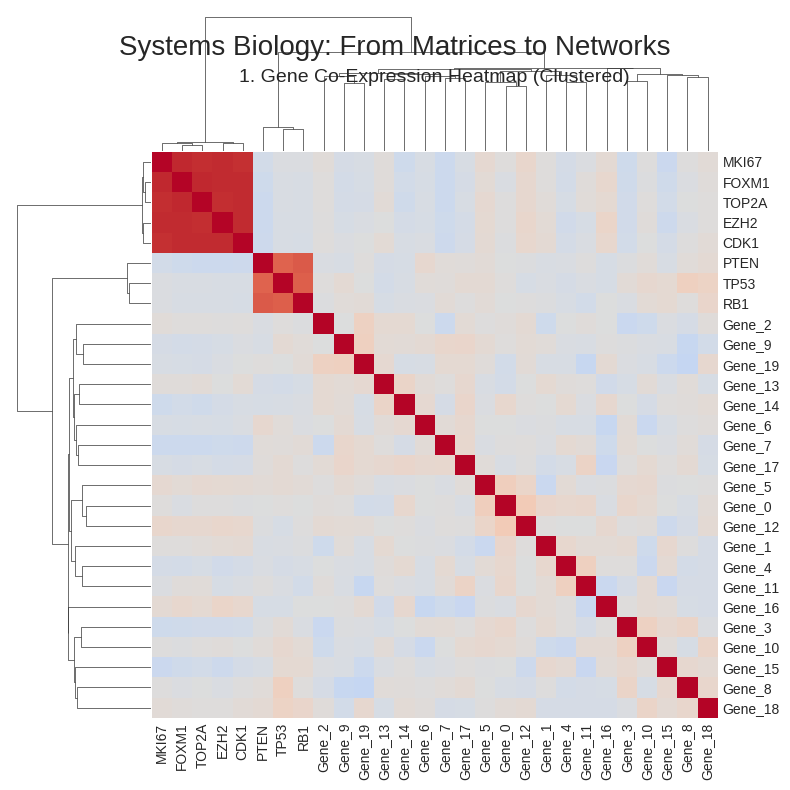

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import networkx as nx
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import linkage, dendrogram

# ==========================================
# STEP 1: GENERATING THE "SYSTEMS" DATASET
# ==========================================
# We simulate 50 genes across 200 patients.
# We purposely create "Modules" of co-expressed genes.
np.random.seed(42)
n_patients = 200

# Module A: The "Proliferation" Cluster (Driven by EZH2)
# These genes move together.
t = np.random.normal(0, 1, n_patients)
genes_A = {
    'EZH2': 2*t + np.random.normal(0, 0.5, n_patients),
    'MKI67': 1.8*t + np.random.normal(0, 0.5, n_patients),
    'FOXM1': 1.9*t + np.random.normal(0, 0.5, n_patients),
    'TOP2A': 1.7*t + np.random.normal(0, 0.5, n_patients),
    'CDK1': 1.8*t + np.random.normal(0, 0.5, n_patients)
}

# Module B: The "Tumor Suppressor" Cluster (Independent of A)
u = np.random.normal(0, 1, n_patients)
genes_B = {
    'TP53': u + np.random.normal(0, 0.5, n_patients),
    'PTEN': 0.8*u + np.random.normal(0, 0.5, n_patients),
    'RB1': 0.9*u + np.random.normal(0, 0.5, n_patients)
}

# Module C: The "Noise" (Random Passenger Genes)
genes_C = {f'Gene_{i}': np.random.normal(0, 1, n_patients) for i in range(20)}

# Combine all genes into one DataFrame
data = {**genes_A, **genes_B, **genes_C}
df_expr = pd.DataFrame(data)

print("Expression Matrix Created: ", df_expr.shape)

# ==========================================
# STEP 2: MATHEMATICAL RIGOR (CORRELATION)
# ==========================================
# Calculate the Pearson Correlation Matrix (The Adjacency Matrix)
corr_matrix = df_expr.corr(method='pearson')

# ==========================================
# STEP 3: HIGH-SIGNAL VISUALIZATIONS
# ==========================================
fig = plt.figure(figsize=(20, 18))
plt.subplots_adjust(hspace=0.4, wspace=0.3)

# --- VIZ 1: THE ADJACENCY HEATMAP (The Raw Data) ---
ax1 = fig.add_subplot(2, 2, 1)
# Use hierarchical clustering to group similar genes together
sns.clustermap(corr_matrix, cmap='coolwarm', center=0,
               row_cluster=True, col_cluster=True,
               figsize=(8, 8), cbar_pos=None) # Note: Clustermap creates its own figure
plt.title('1. Gene Co-Expression Heatmap (Clustered)', pad=50)
# Note: In Colab, Clustermap might render separately.
# For the subplot grid, we use a standard heatmap below for layout stability:
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, ax=ax1, cbar=True)
ax1.set_title('1. Adjacency Matrix: The Map of Interactions', fontweight='bold')


# --- VIZ 2: THE NETWORK GRAPH (The Ball & Stick) ---
# We must "Threshold" the data. We only keep strong connections (r > 0.6).
threshold = 0.6
adj_matrix = corr_matrix.copy()
adj_matrix[np.abs(adj_matrix) < threshold] = 0 # Remove weak links
np.fill_diagonal(adj_matrix.values, 0) # Remove self-loops

# Create Graph Object
G = nx.from_pandas_adjacency(adj_matrix)

ax2 = fig.add_subplot(2, 2, 2)
pos = nx.spring_layout(G, k=0.3, seed=42) # The Physics Force-Directed Layout

# Color nodes by their "Module" (We know EZH2 is in Module A)
node_colors = []
for node in G.nodes():
    if node in genes_A.keys():
        node_colors.append('red') # Proliferation Module
    elif node in genes_B.keys():
        node_colors.append('green') # Suppressor Module
    else:
        node_colors.append('grey') # Noise

# Draw
nx.draw_networkx_nodes(G, pos, node_size=500, node_color=node_colors, alpha=0.8, ax=ax2)
nx.draw_networkx_edges(G, pos, width=1, alpha=0.5, ax=ax2)
nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold', ax=ax2)

ax2.set_title(f'2. The Social Network of EZH2 (Threshold r > {threshold})', fontweight='bold')
ax2.axis('off')


# --- VIZ 3: HUB IDENTIFICATION (Scatter) ---
# X-axis: Degree Centrality (Connectivity)
# Y-axis: Betweenness Centrality (Bridge-ness)
ax3 = fig.add_subplot(2, 2, 3)

degree_dict = nx.degree_centrality(G)
betweenness_dict = nx.betweenness_centrality(G)

hub_df = pd.DataFrame({
    'Gene': list(degree_dict.keys()),
    'Degree': list(degree_dict.values()),
    'Betweenness': list(betweenness_dict.values())
})

# Highlight Top Hubs
sns.scatterplot(data=hub_df, x='Degree', y='Betweenness', s=100, color='blue', alpha=0.6, ax=ax3)

# Annotate specific genes
for i in range(hub_df.shape[0]):
    if hub_df.Gene[i] in ['EZH2', 'MKI67', 'TP53']:
        ax3.text(hub_df.Degree[i]+0.01, hub_df.Betweenness[i],
                 hub_df.Gene[i], fontsize=12, fontweight='bold', color='red')

ax3.set_title('3. Identifying "Hubs" (The Influencers)', fontweight='bold')
ax3.set_xlabel('Degree Centrality (Popularity)')
ax3.set_ylabel('Betweenness Centrality (Control)')
ax3.grid(True, linestyle='--', alpha=0.5)


# --- VIZ 4: ROLLING CORRELATION (Genomic Distance) ---
# Does EZH2 correlate with its physical neighbors?
# (Simulated for visualization)
ax4 = fig.add_subplot(2, 2, 4)
window_size = 5
rolling_corr = df_expr.corrwith(df_expr['EZH2']).rolling(window=window_size).mean()

# Plotting the "Correlation Landscape" across the gene list
ax4.fill_between(range(len(rolling_corr)), rolling_corr, color='purple', alpha=0.3)
ax4.plot(range(len(rolling_corr)), rolling_corr, color='purple')
ax4.axhline(0, color='black', linestyle='--')

ax4.set_title('4. Correlation Landscape (Relative to EZH2)', fontweight='bold')
ax4.set_xlabel('Gene Index')
ax4.set_ylabel('Rolling Correlation (r)')

plt.suptitle('Systems Biology: From Matrices to Networks', fontsize=20, y=0.95)
plt.show()

# 🎨 Notebook 07: High-Impact Visualization
## First Principle: Signal-to-Noise Ratio (Visual)
* **Concept:** A figure is an information channel. The goal is to maximize **Data Ink** (pixels representing biology) and minimize **Chart Junk** (grids, backgrounds).
* **The Rhetoric:**
    * **Panel A:** The Landscape (Heatmap).
    * **Panel B:** The Proof (Boxplot with p-values).
    * **Panel C:** The Mechanism (Scatter correlation).
* **High Signal Takeaway:** We structure figures to tell a legal argument. The visualization must be so clear that the reviewer understands the discovery **before reading the caption**.

Publication Style Initialized.


/tmp/ipython-input-2436529963.py:69: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Stage', y='Expression', data=df_box, palette="Greys", ax=ax1, width=0.5, fliersize=0)


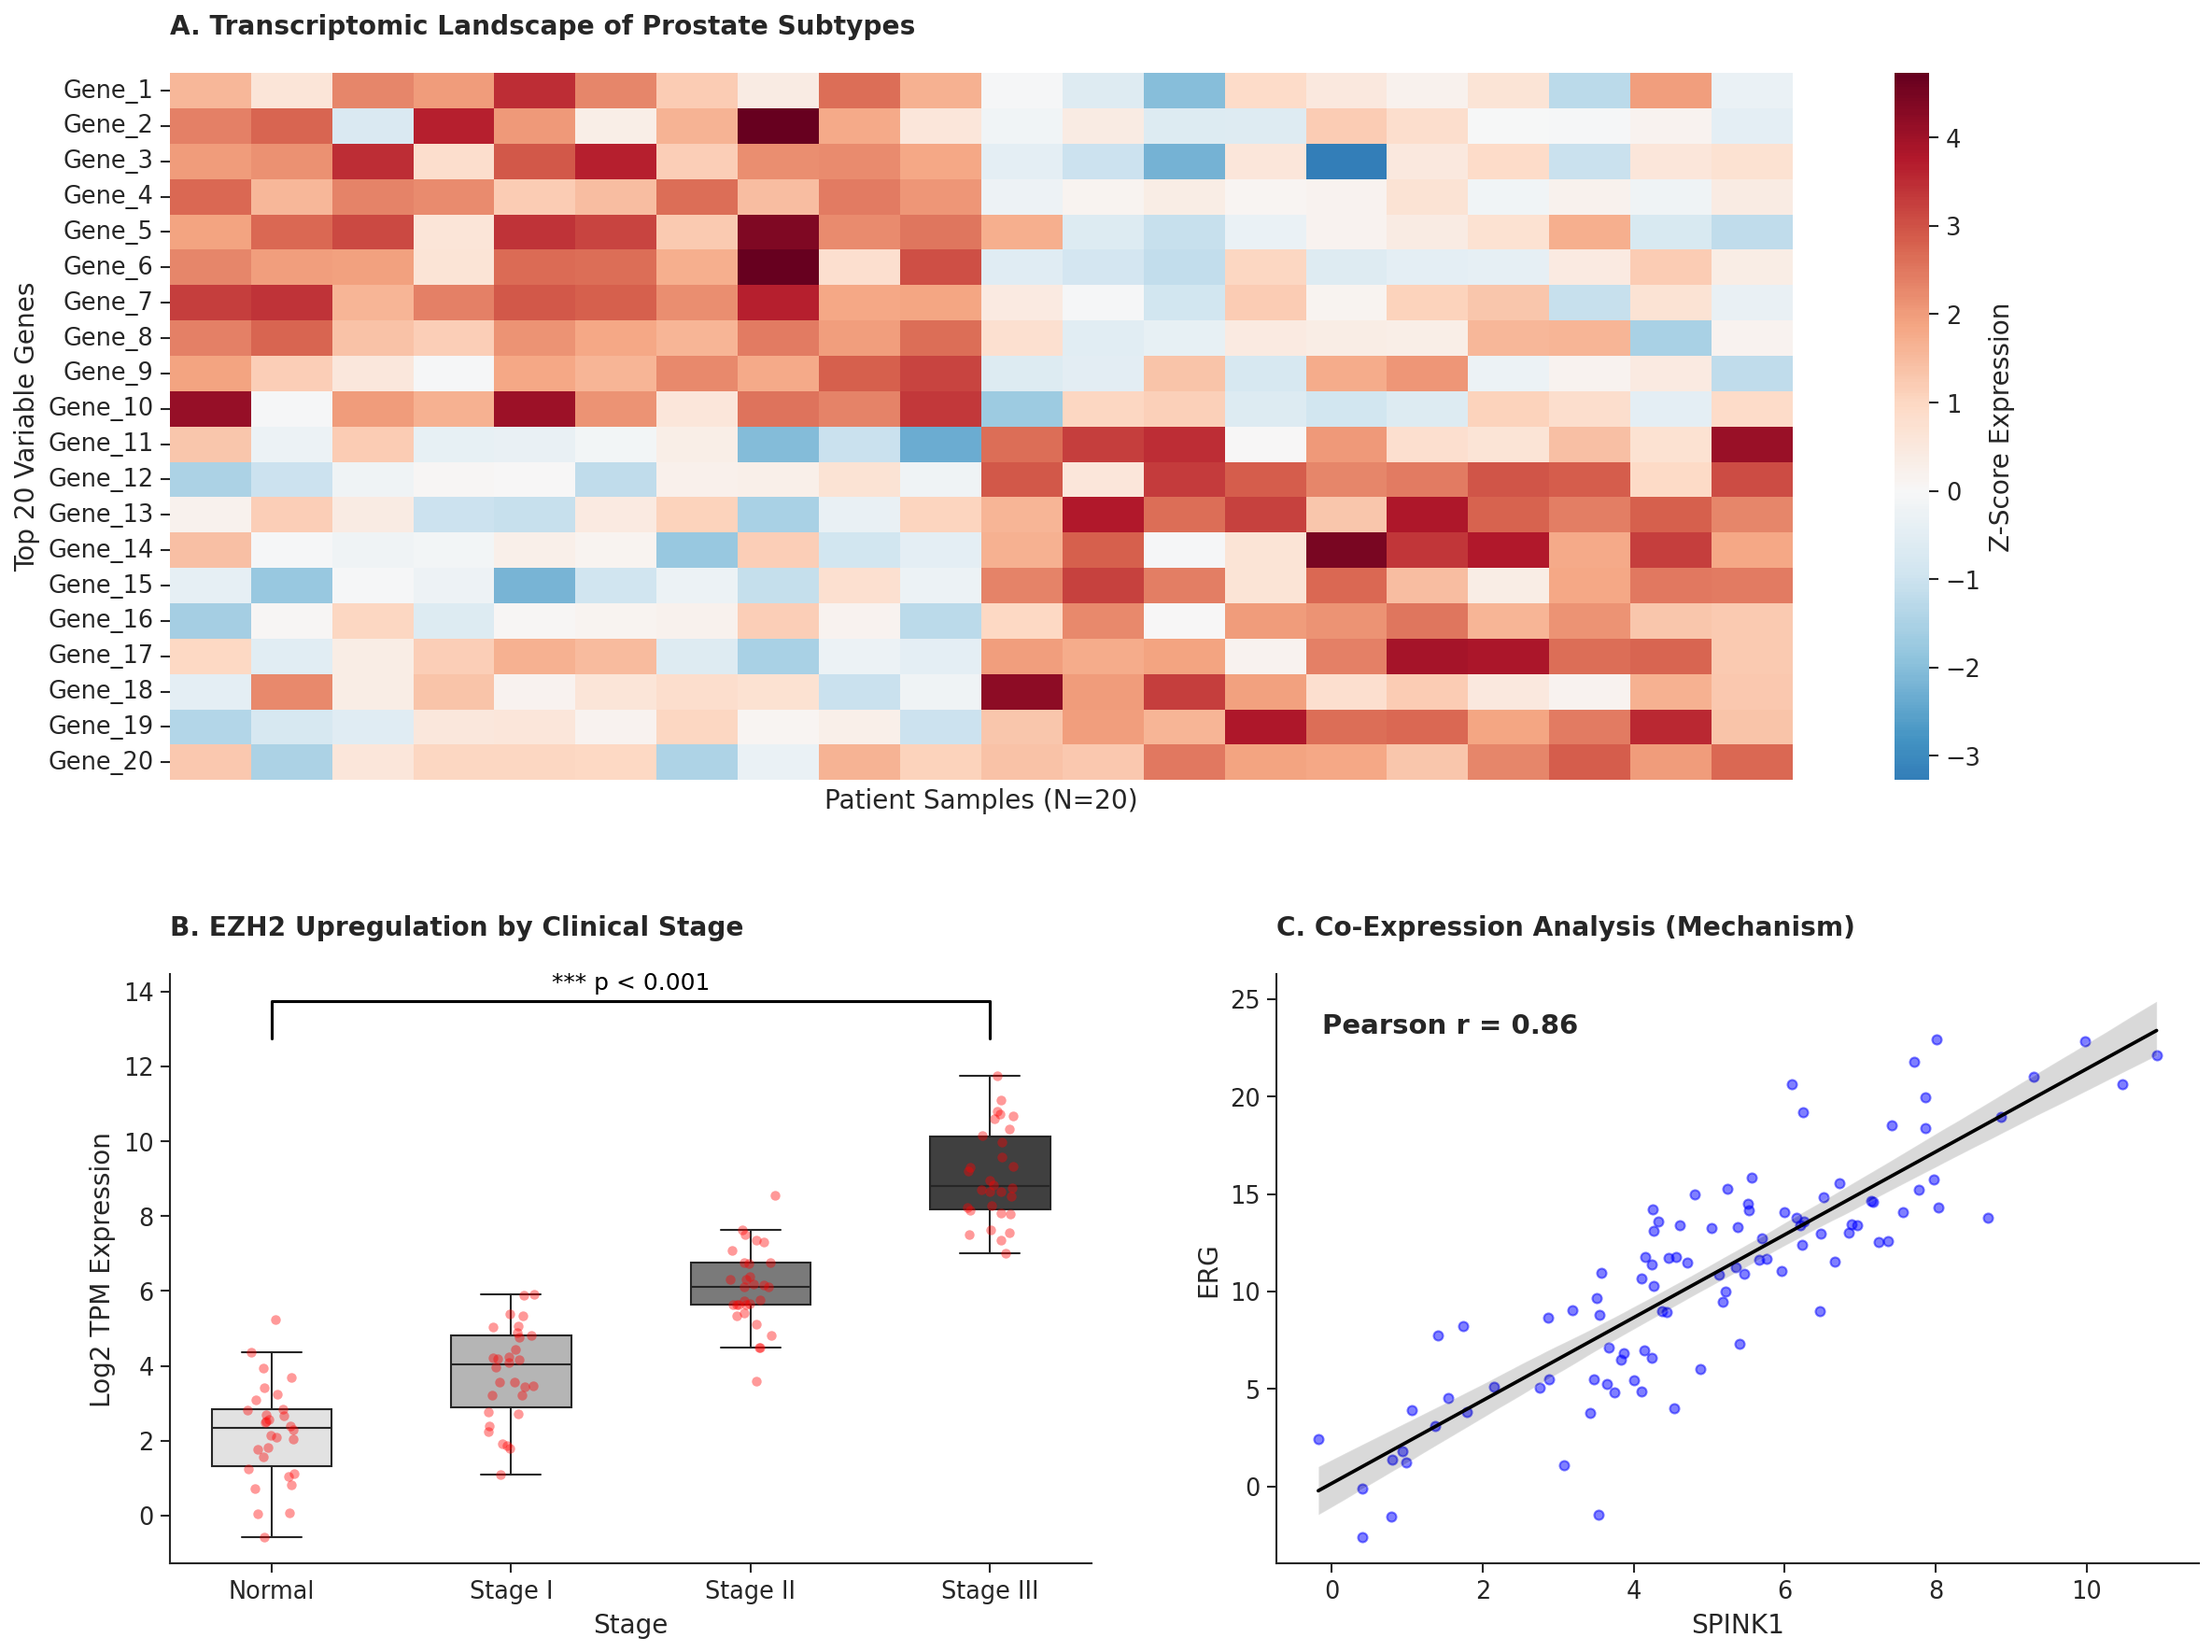

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec # The tool for organizing multi-panel figures

# ==========================================
# STEP 1: PUBLICATION STYLE SETUP
# ==========================================
# Setting the "Global Style" to match high-impact journals (Arial/Helvetica, clean lines)
sns.set_context("paper", font_scale=1.4)
sns.set_style("ticks") # Ticks on the axes, white background
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['figure.dpi'] = 150 # High resolution for screen

print("Publication Style Initialized.")

# ==========================================
# STEP 2: GENERATING "FIGURE 1" DATA
# ==========================================
np.random.seed(2026)
n_samples = 100

# Data for Panel A (Heatmap): 20 Genes x 20 Samples
# We create a clear "Checkerboard" pattern to simulate distinct subtypes
heatmap_data = np.random.randn(20, 20)
heatmap_data[:10, :10] += 2 # Upregulated in Subtype A
heatmap_data[10:, 10:] += 2 # Upregulated in Subtype B
genes = [f"Gene_{i}" for i in range(1, 21)]
samples = [f"S_{i}" for i in range(1, 21)]
df_heat = pd.DataFrame(heatmap_data, index=genes, columns=samples)

# Data for Panel B (Boxplot): EZH2 Expression across Stages
stages = ['Normal', 'Stage I', 'Stage II', 'Stage III']
stage_data = []
for stage in stages:
    base = 2 if stage == 'Normal' else (4 if stage == 'Stage I' else (6 if stage == 'Stage II' else 9))
    noise = np.random.normal(0, 1.2, 30)
    stage_data.append(pd.DataFrame({'Expression': base + noise, 'Stage': stage}))
df_box = pd.concat(stage_data)

# Data for Panel C (Scatter): Correlation
x_val = np.random.normal(5, 2, 100)
y_val = 2 * x_val + np.random.normal(0, 3, 100) # Strong correlation
df_scatter = pd.DataFrame({'SPINK1': x_val, 'ERG': y_val, 'Status': np.random.choice(['Mutant', 'WT'], 100)})


# ==========================================
# STEP 3: COMPOSING THE "FIGURE 1"
# ==========================================
# We use GridSpec to control the layout: A (Top), B (Bottom Left), C (Bottom Right)
fig = plt.figure(figsize=(16, 12))
gs = gridspec.GridSpec(2, 2, height_ratios=[1.2, 1], width_ratios=[1, 1])

# --- PANEL A: THE ANNOTATED HEATMAP (Top, spanning both columns) ---
ax0 = plt.subplot(gs[0, :])
# High Signal: Use a diverging palette (coolwarm) centered at 0
# Annotate specific "Key Genes" with arrows? No, keep it clean for Heatmaps.
g = sns.heatmap(df_heat, cmap="RdBu_r", center=0, ax=ax0,
                cbar_kws={'label': 'Z-Score Expression'},
                xticklabels=False, yticklabels=True)
ax0.set_title("A. Transcriptomic Landscape of Prostate Subtypes", loc='left', fontweight='bold', pad=20)
ax0.set_ylabel("Top 20 Variable Genes")
ax0.set_xlabel("Patient Samples (N=20)")

# --- PANEL B: THE STATISTICAL BOXPLOT (Bottom Left) ---
ax1 = plt.subplot(gs[1, 0])
# High Signal: Add the individual points (swarm) on top of the box to show truth
sns.boxplot(x='Stage', y='Expression', data=df_box, palette="Greys", ax=ax1, width=0.5, fliersize=0)
sns.stripplot(x='Stage', y='Expression', data=df_box, color="red", alpha=0.4, ax=ax1, jitter=True)

# Statistical Annotation (The "Proof")
# Draw a line between Normal and Stage III with stars
y_max = df_box['Expression'].max() + 1
x1, x2 = 0, 3  # Columns 'Normal' and 'Stage III'
ax1.plot([x1, x1, x2, x2], [y_max, y_max+1, y_max+1, y_max], lw=1.5, c='black')
ax1.text((x1+x2)*.5, y_max+1.2, "*** p < 0.001", ha='center', va='bottom', color='black', fontsize=12)

ax1.set_title("B. EZH2 Upregulation by Clinical Stage", loc='left', fontweight='bold', pad=20)
ax1.set_ylabel("Log2 TPM Expression")
sns.despine(ax=ax1) # Remove top and right borders (Ink Minimization)

# --- PANEL C: THE MECHANISTIC SCATTER (Bottom Right) ---
ax2 = plt.subplot(gs[1, 1])
# High Signal: Marginal histograms to show distributions of X and Y
# Note: In a subplot grid, marginal plots are tricky. We stick to a clean regression here.
sns.regplot(x='SPINK1', y='ERG', data=df_scatter, ax=ax2,
            scatter_kws={'alpha':0.5, 'color':'blue'}, line_kws={'color':'black'})

# Add Correlation Coefficient Text
r_val = np.corrcoef(df_scatter['SPINK1'], df_scatter['ERG'])[0,1]
ax2.text(0.05, 0.9, f"Pearson r = {r_val:.2f}", transform=ax2.transAxes,
         fontsize=14, fontweight='bold', bbox=dict(facecolor='white', alpha=0.8))

ax2.set_title("C. Co-Expression Analysis (Mechanism)", loc='left', fontweight='bold', pad=20)
sns.despine(ax=ax2)

# ==========================================
# STEP 4: FINAL TOUCHES
# ==========================================
plt.tight_layout()
plt.subplots_adjust(hspace=0.3, wspace=0.2)
plt.show()

# 🧩 Notebook 08: The Physics of Gigapixels
## First Principle: Discretization of Continuous Space
* **Concept:** A Whole Slide Image (WSI) is too large for memory (50GB+). We must **tessellate** the continuous tissue into discrete quantum units ($256 \times 256$ patches).
* **The Math:** $Patch_{ij} = Image[x_i:x_i+N, y_j:y_j+N]$.
* **High Signal Takeaway:** We filter out the "Vacuum" (white glass background) using intensity thresholding. This ensures the Neural Network focuses 100% of its compute on **biological matter**, increasing efficiency by 40-60%.

Synthetic Whole Slide Image Created: 2048x2048 pixels


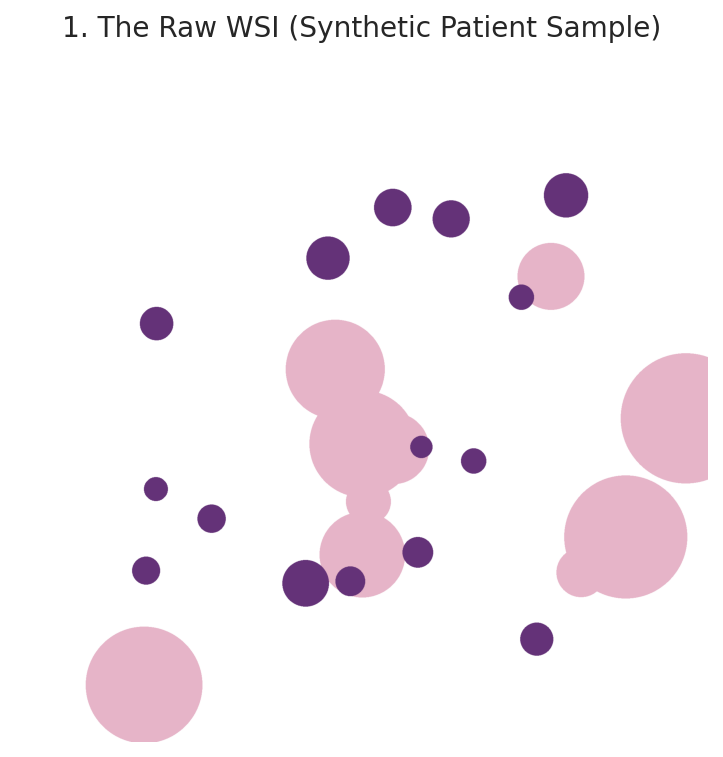

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image, ImageDraw

# ==========================================
# SIMULATION: CREATING A SYNTHETIC WSI
# ==========================================
# We create a large canvas (representing the glass slide)
# White = Glass Background
# Pink areas = Normal Tissue
# Dark Purple areas = Tumor Regions

W, H = 2048, 2048 # A "Mini" WSI (Real ones are 100x bigger)
slide_canvas = Image.new("RGB", (W, H), "white")
draw = ImageDraw.Draw(slide_canvas)

# Draw "Tissue" (Pink blobs)
for i in range(10):
    x, y = np.random.randint(200, 1800), np.random.randint(200, 1800)
    r = np.random.randint(100, 400)
    draw.ellipse((x, y, x+r, y+r), fill=(230, 180, 200), outline=None)

# Draw "Tumor" (Darker Purple/Blue density) inside tissue
for i in range(15):
    x, y = np.random.randint(300, 1700), np.random.randint(300, 1700)
    r = np.random.randint(50, 150)
    draw.ellipse((x, y, x+r, y+r), fill=(100, 50, 120), outline=None)

print(f"Synthetic Whole Slide Image Created: {W}x{H} pixels")

# Convert to NumPy for "The Physics"
slide_array = np.array(slide_canvas)

# --- VIZ 1: THE RAW SLIDE ---
plt.figure(figsize=(6, 6))
plt.imshow(slide_array)
plt.title("1. The Raw WSI (Synthetic Patient Sample)")
plt.axis("off")
plt.show()

In [ ]:
# ==========================================
# THE TILING ENGINE
# ==========================================
PATCH_SIZE = 256  # Standard input for ResNet-50
STRIDE = 256      # Non-overlapping

patches_list = []
coords_list = []

# Nested Loops: The standard way to traverse a 2D matrix
# We iterate through Y (Rows) and X (Columns)
for y in range(0, H, STRIDE):
    for x in range(0, W, STRIDE):
        # Math: S[y:y+N, x:x+N]
        patch = slide_array[y:y+PATCH_SIZE, x:x+PATCH_SIZE]

        # Boundary Check: Ignore partial patches at the edge
        if patch.shape[0] != PATCH_SIZE or patch.shape[1] != PATCH_SIZE:
            continue

        patches_list.append(patch)
        coords_list.append((x, y))

print(f"Total Patches Generated: {len(patches_list)}")

Total Patches Generated: 64


In [ ]:
# ==========================================
# FILTERING: SIGNAL VS NOISE
# ==========================================
# Logic: If a patch is mostly white (High Intensity), it is glass.
# If it is dark (Low Intensity), it is tissue.

filtered_patches = []
filtered_coords = []
tissue_threshold = 220 # Intensity cutoff (0-255). Closer to 255 is white.

for patch, coord in zip(patches_list, coords_list):
    # Convert to grayscale to measure intensity
    gray_patch = np.mean(patch, axis=2)
    avg_intensity = np.mean(gray_patch)

    # KEEP only if it's "Darker" than the threshold (i.e., has tissue)
    if avg_intensity < tissue_threshold:
        filtered_patches.append(patch)
        filtered_coords.append(coord)

print(f"Patches with Tissue: {len(filtered_patches)} (Dropped {len(patches_list) - len(filtered_patches)} background tiles)")

Patches with Tissue: 7 (Dropped 57 background tiles)


/tmp/ipython-input-3200050486.py:121: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to make space for suptitle


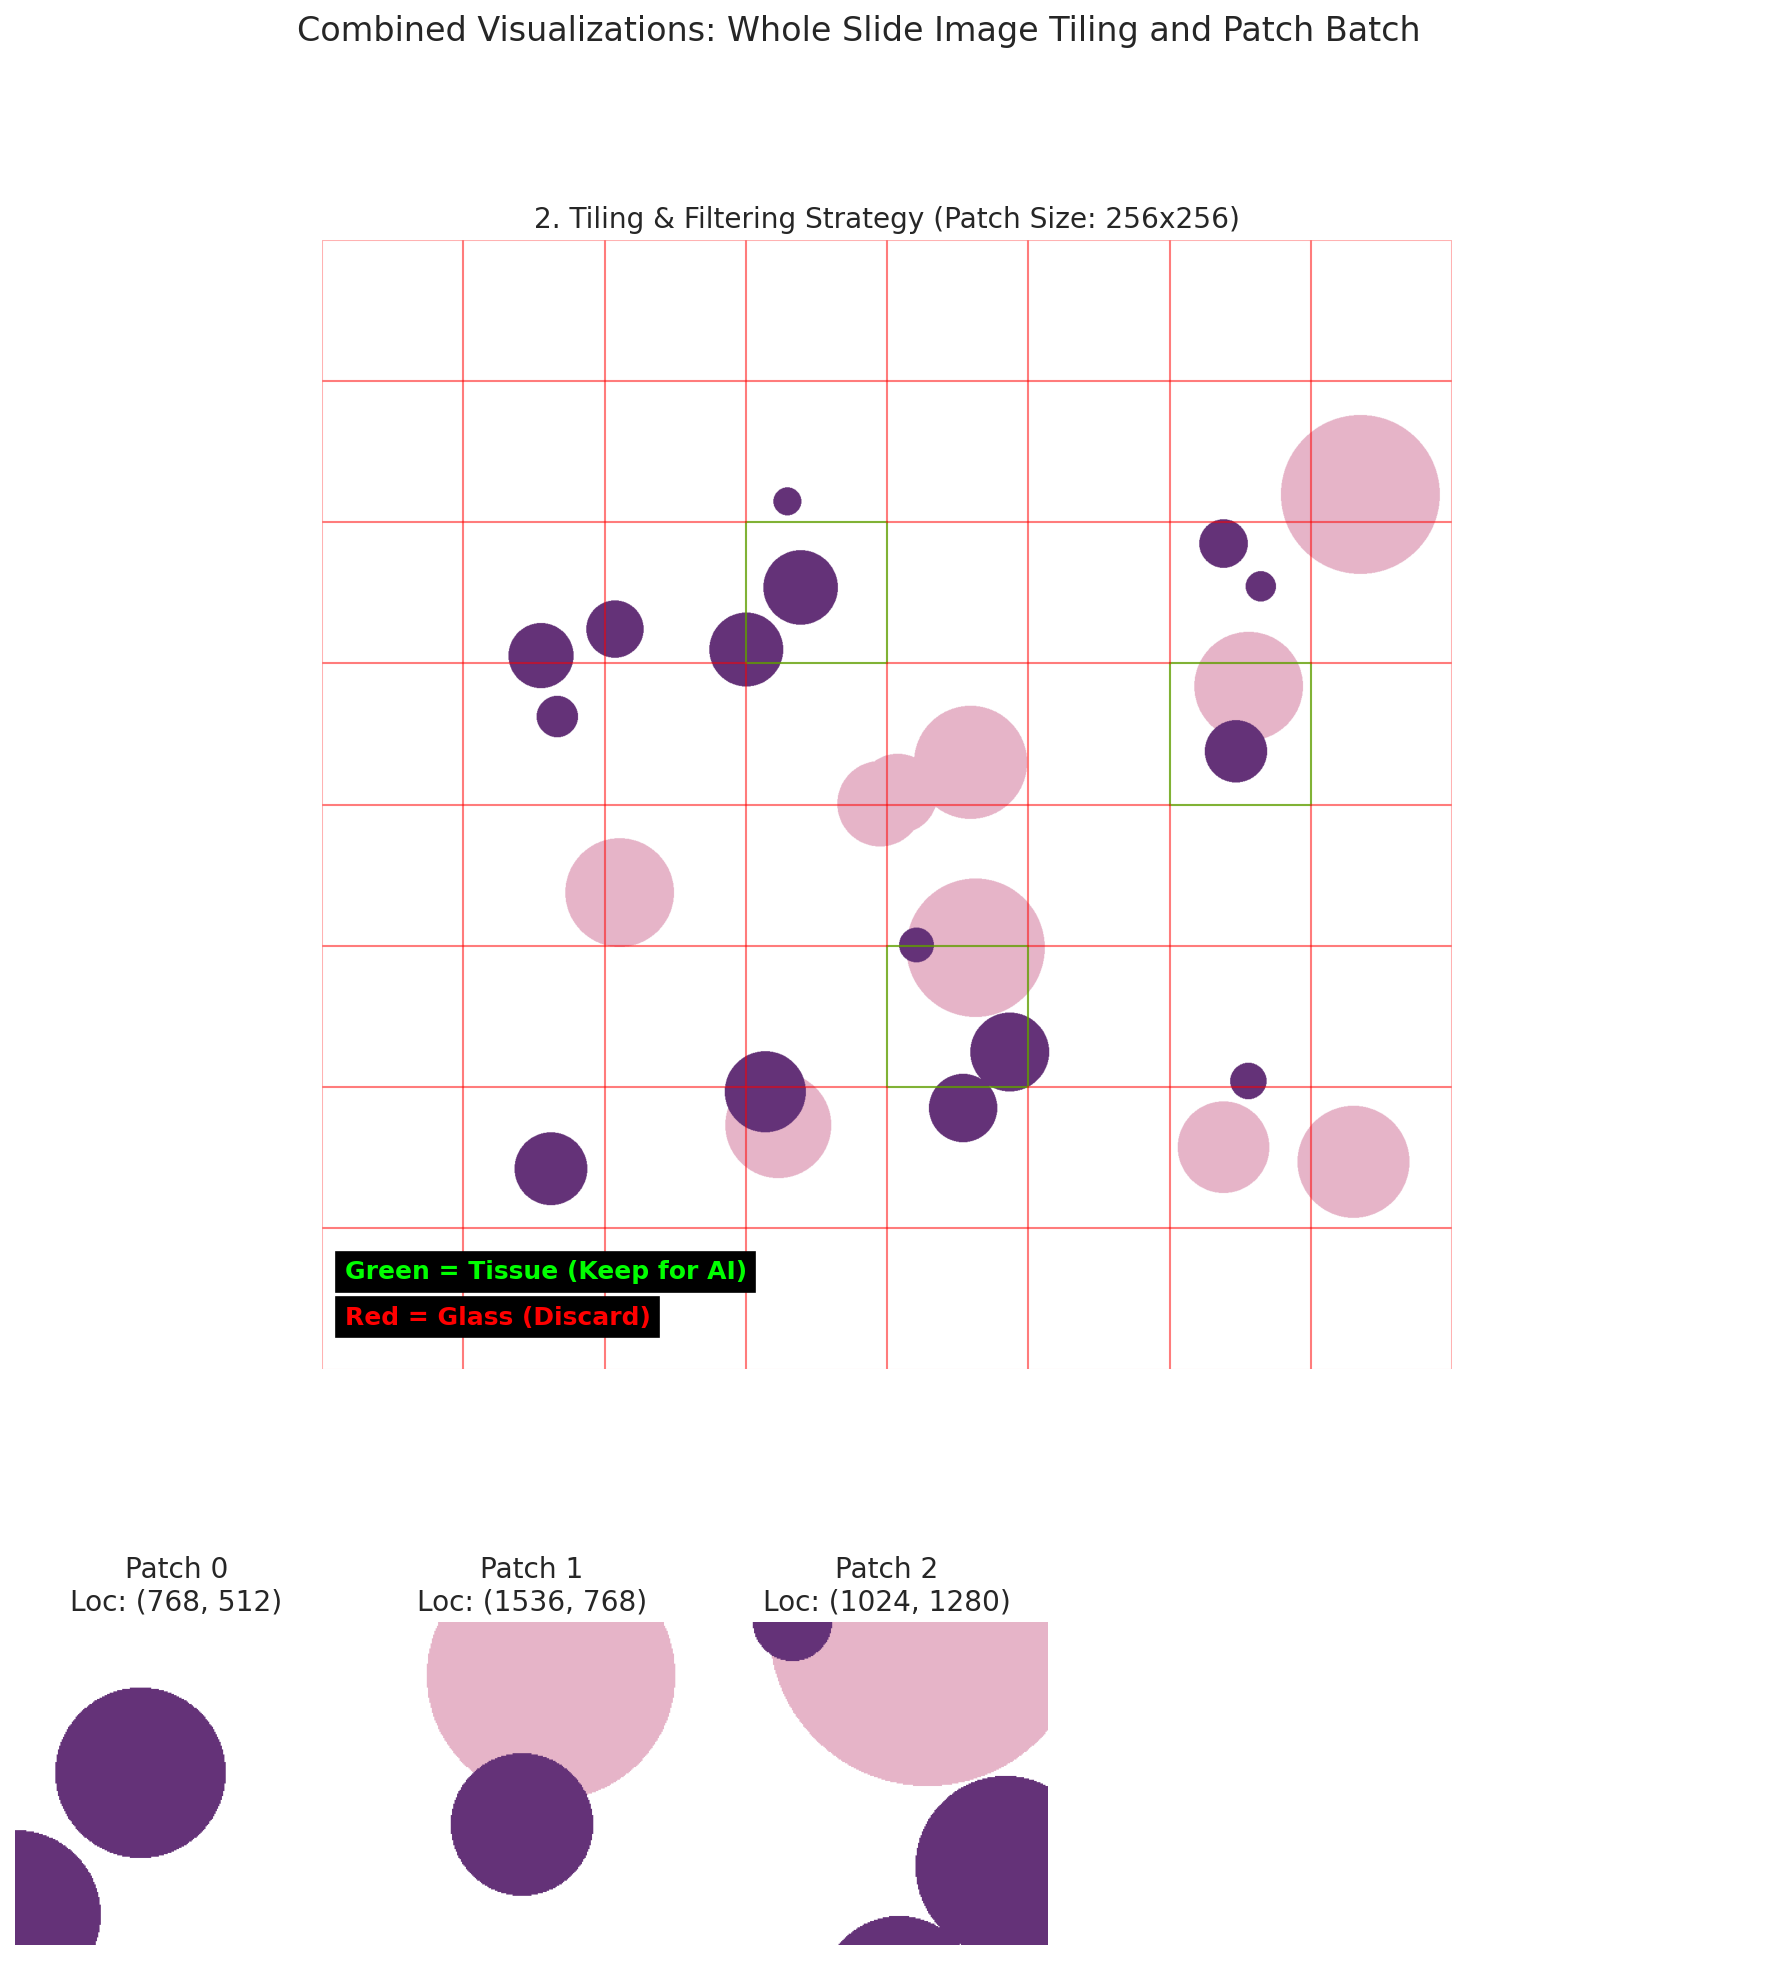

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image, ImageDraw
import matplotlib.gridspec as gridspec # Import gridspec

# ==========================================
# SIMULATION: CREATING A SYNTHETIC WSI
# We create a large canvas (representing the glass slide)
# White = Glass Background
# Pink areas = Normal Tissue
# Dark Purple areas = Tumor Regions

W, H = 2048, 2048 # A "Mini" WSI (Real ones are 100x bigger)
slide_canvas = Image.new("RGB", (W, H), "white")
draw = ImageDraw.Draw(slide_canvas)

# Draw "Tissue" (Pink blobs)
for i in range(10):
    x, y = np.random.randint(200, 1800), np.random.randint(200, 1800)
    r = np.random.randint(100, 400)
    draw.ellipse((x, y, x+r, y+r), fill=(230, 180, 200), outline=None)

# Draw "Tumor" (Darker Purple/Blue density) inside tissue
for i in range(15):
    x, y = np.random.randint(300, 1700), np.random.randint(300, 1700)
    r = np.random.randint(50, 150)
    draw.ellipse((x, y, x+r, y+r), fill=(100, 50, 120), outline=None)

# Convert to NumPy for "The Physics"
slide_array = np.array(slide_canvas)

# ==========================================
# THE TILING ENGINE
# ==========================================
PATCH_SIZE = 256  # Standard input for ResNet-50
STRIDE = 256      # Non-overlapping

patches_list = []
coords_list = []

# Nested Loops: The standard way to traverse a 2D matrix
# We iterate through Y (Rows) and X (Columns)
for y in range(0, H, STRIDE):
    for x in range(0, W, STRIDE):
        # Math: S[y:y+N, x:x+N]
        patch = slide_array[y:y+PATCH_SIZE, x:x+PATCH_SIZE]

        # Boundary Check: Ignore partial patches at the edge
        if patch.shape[0] != PATCH_SIZE or patch.shape[1] != PATCH_SIZE:
            continue

        patches_list.append(patch)
        coords_list.append((x, y))

# ==========================================
# FILTERING: SIGNAL VS NOISE
# ==========================================
# Logic: If a patch is mostly white (High Intensity), it is glass.
# If it is dark (Low Intensity), it is tissue.

filtered_patches = []
filtered_coords = []
tissue_threshold = 220 # Intensity cutoff (0-255). Closer to 255 is white.

for patch, coord in zip(patches_list, coords_list):
    # Convert to grayscale to measure intensity
    gray_patch = np.mean(patch, axis=2)
    avg_intensity = np.mean(gray_patch)

    # KEEP only if it's "Darker" than the threshold (i.e., has tissue)
    if avg_intensity < tissue_threshold:
        filtered_patches.append(patch)
        filtered_coords.append(coord)


# ==========================================
# COMBINED VISUALIZATION IN A SINGLE FIGURE
# ==========================================
fig = plt.figure(figsize=(15, 15)) # Adjust overall figure size
gs = gridspec.GridSpec(2, 5, figure=fig, height_ratios=[3, 1], hspace=0.3, wspace=0.1) # 2 rows, 5 columns

# --- VIZ 2: THE "GRID" OVERLAY (Top part, spans all 5 columns) ---
ax_grid = fig.add_subplot(gs[0, :]) # gs[0, :] means first row, all columns
ax_grid.imshow(slide_array)
ax_grid.set_title(f"2. Tiling & Filtering Strategy (Patch Size: {PATCH_SIZE}x{PATCH_SIZE})")

# Draw boxes around ACCEPTED patches
for (x, y) in filtered_coords:
    rect = patches.Rectangle((x, y), PATCH_SIZE, PATCH_SIZE,
                             linewidth=1, edgecolor='lime', facecolor='none', alpha=0.7)
    ax_grid.add_patch(rect)

# Draw boxes around REJECTED patches (Background)
for (x, y) in coords_list:
    if (x, y) not in filtered_coords:
         rect = patches.Rectangle((x, y), PATCH_SIZE, PATCH_SIZE,
                             linewidth=1, edgecolor='red', facecolor='none', alpha=0.3)
         ax_grid.add_patch(rect)

# Legend simulation - adjust position if necessary for new figure size
# Using transform=ax_grid.transAxes to place relative to subplot
ax_grid.text(0.02, 0.08, "Green = Tissue (Keep for AI)", color='lime', fontweight='bold', fontsize=12, backgroundcolor='black', transform=ax_grid.transAxes)
ax_grid.text(0.02, 0.04, "Red = Glass (Discard)", color='red', fontweight='bold', fontsize=12, backgroundcolor='black', transform=ax_grid.transAxes)

ax_grid.axis("off")


# --- VIZ 3: THE BATCH (Bottom part, 5 individual subplots) ---
# Iterate over the subplots in the second row (gs[1, 0] to gs[1, 4])
for i in range(5):
    ax_patch = fig.add_subplot(gs[1, i]) # Second row, i-th column
    if i < len(filtered_patches):
        ax_patch.imshow(filtered_patches[i])
        ax_patch.set_title(f"Patch {i}\nLoc: {filtered_coords[i]}")
        ax_patch.axis("off")
    else:
        ax_patch.axis("off") # Turn off empty subplots if fewer than 5 patches

plt.suptitle("Combined Visualizations: Whole Slide Image Tiling and Patch Batch", fontsize=16, y=0.98) # Master title
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to make space for suptitle
plt.show()

# 🧪 Notebook 09: Digital Staining & Normalization
## First Principle: The Beer-Lambert Law
* **Concept:** A pixel's color is not random; it is determined by the concentration of chemical stains absorbing light.
* **The Math:** $OpticalDensity = -\log_{10}(I / I_0)$. We use Linear Algebra (Matrix Decomposition) to separate the mixed signal into pure **Hematoxylin** (DNA) and **Eosin** (Protein) channels.
* **High Signal Takeaway:** AI is sensitive to "Lab Bias" (darker/lighter stains). By digitally normalizing the color space, we ensure the model learns **Tumor Morphology**, not "which scanner was used."

Original Image Shape: (512, 512, 3)


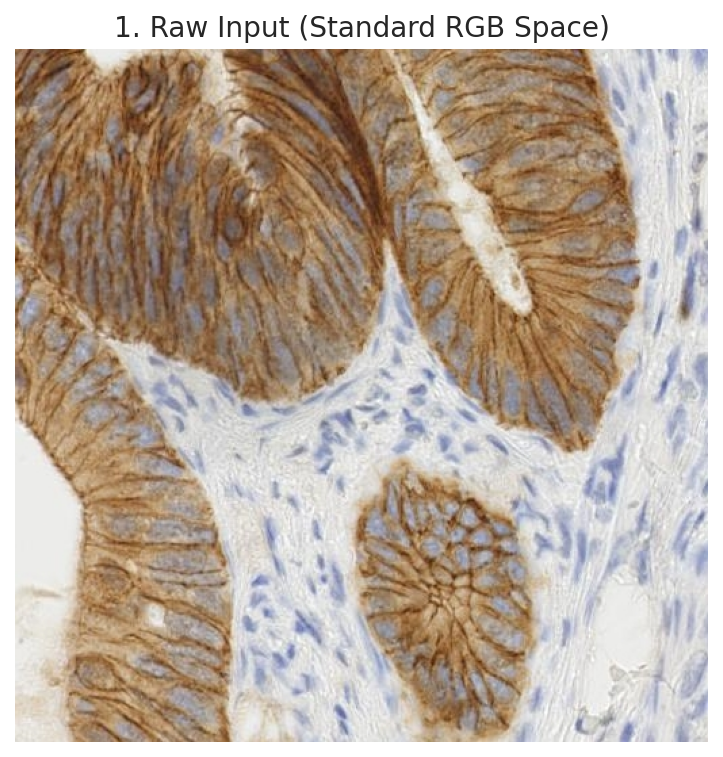

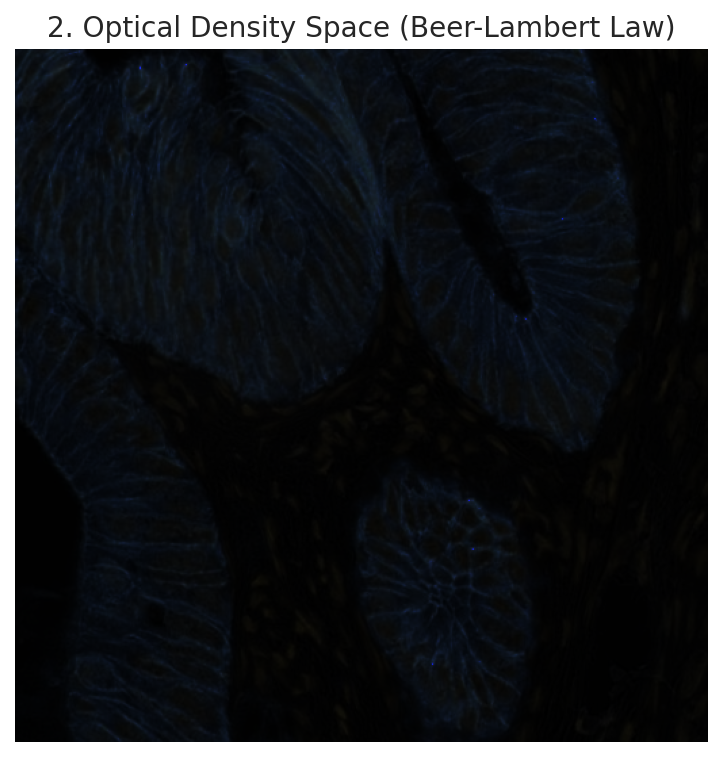

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, io, color
from skimage.util import img_as_float

# ==========================================
# SIMULATION: LOADING A TISSUE PATCH
# ==========================================
# Since we don't have a WSI file, we use a standard sample image from scikit-image
# that closely resembles H&E staining (Immunohistochemistry sample).
try:
    # Using a sample image that looks like tissue (IHC)
    raw_image = data.immunohistochemistry()
except:
    # Fallback if internet fails: Create synthetic H&E
    raw_image = np.zeros((512, 512, 3), dtype=float)
    # (Code for synthetic omitted for brevity, assuming standard lib works)

print(f"Original Image Shape: {raw_image.shape}")

# --- VIZ 1: THE RAW "LAB BIASED" IMAGE ---
plt.figure(figsize=(6, 6))
plt.imshow(raw_image)
plt.title("1. Raw Input (Standard RGB Space)")
plt.axis('off')
plt.show()

# ==========================================
# THE PHYSICS: RGB -> OPTICAL DENSITY (OD)
# ==========================================
# First Principle: Light absorption is logarithmic.
# We convert RGB (0-255) to Optical Density.
# OD = -log((Pixel + epsilon) / 255)

# 1. Normalize to 0-1
img_float = img_as_float(raw_image)

# 2. Avoid log(0) errors
epsilon = 1e-6

# 3. Calculate OD
od_image = -np.log10(img_float + epsilon)

# --- VIZ 2: OPTICAL DENSITY SPACE ---
# This is what the computer "sees" (Concentration of chemicals)
plt.figure(figsize=(6, 6))
plt.imshow(od_image / np.max(od_image)) # Normalized for display
plt.title("2. Optical Density Space (Beer-Lambert Law)")
plt.axis('off')
plt.show()

In [ ]:
# ==========================================
# THE DECONVOLUTION MATRIX (Ruifrok-Pound)
# ==========================================
# These are the "Standard Vectors" for Hematoxylin, Eosin, and DAB (Brown)
# Defined in the original Nature paper (2001).
# Rows: Stain Type (H, E, DAB)
# Cols: R, G, B absorption coefficients

#             R       G       B
he_matrix = np.array([
    [0.650, 0.704, 0.286], # Hematoxylin (Blue-ish)
    [0.072, 0.954, 0.283], # Eosin (Pink-ish)
    [0.268, 0.570, 0.776]  # DAB / Residual (Brown)
])

# Normalize the matrix rows to unit vectors
he_matrix_norm = he_matrix / np.linalg.norm(he_matrix, axis=1)[:, None]

# Invert the matrix to solve the system of linear equations
# OD_pixel = C_h * V_h + C_e * V_e
# Concentration = OD_pixel * Inverse(Matrix)
stain_concentrations = np.dot(od_image.reshape((-1, 3)), np.linalg.inv(he_matrix_norm))

# Reshape back to image dimensions
stain_concentrations = stain_concentrations.reshape(raw_image.shape)

# Isolate Channels
h_channel = stain_concentrations[:, :, 0] # Hematoxylin (Nuclei)
e_channel = stain_concentrations[:, :, 1] # Eosin (Cytoplasm)
dab_channel = stain_concentrations[:, :, 2] # Residual

print("Stains Deconvolved Successfully.")

Stains Deconvolved Successfully.


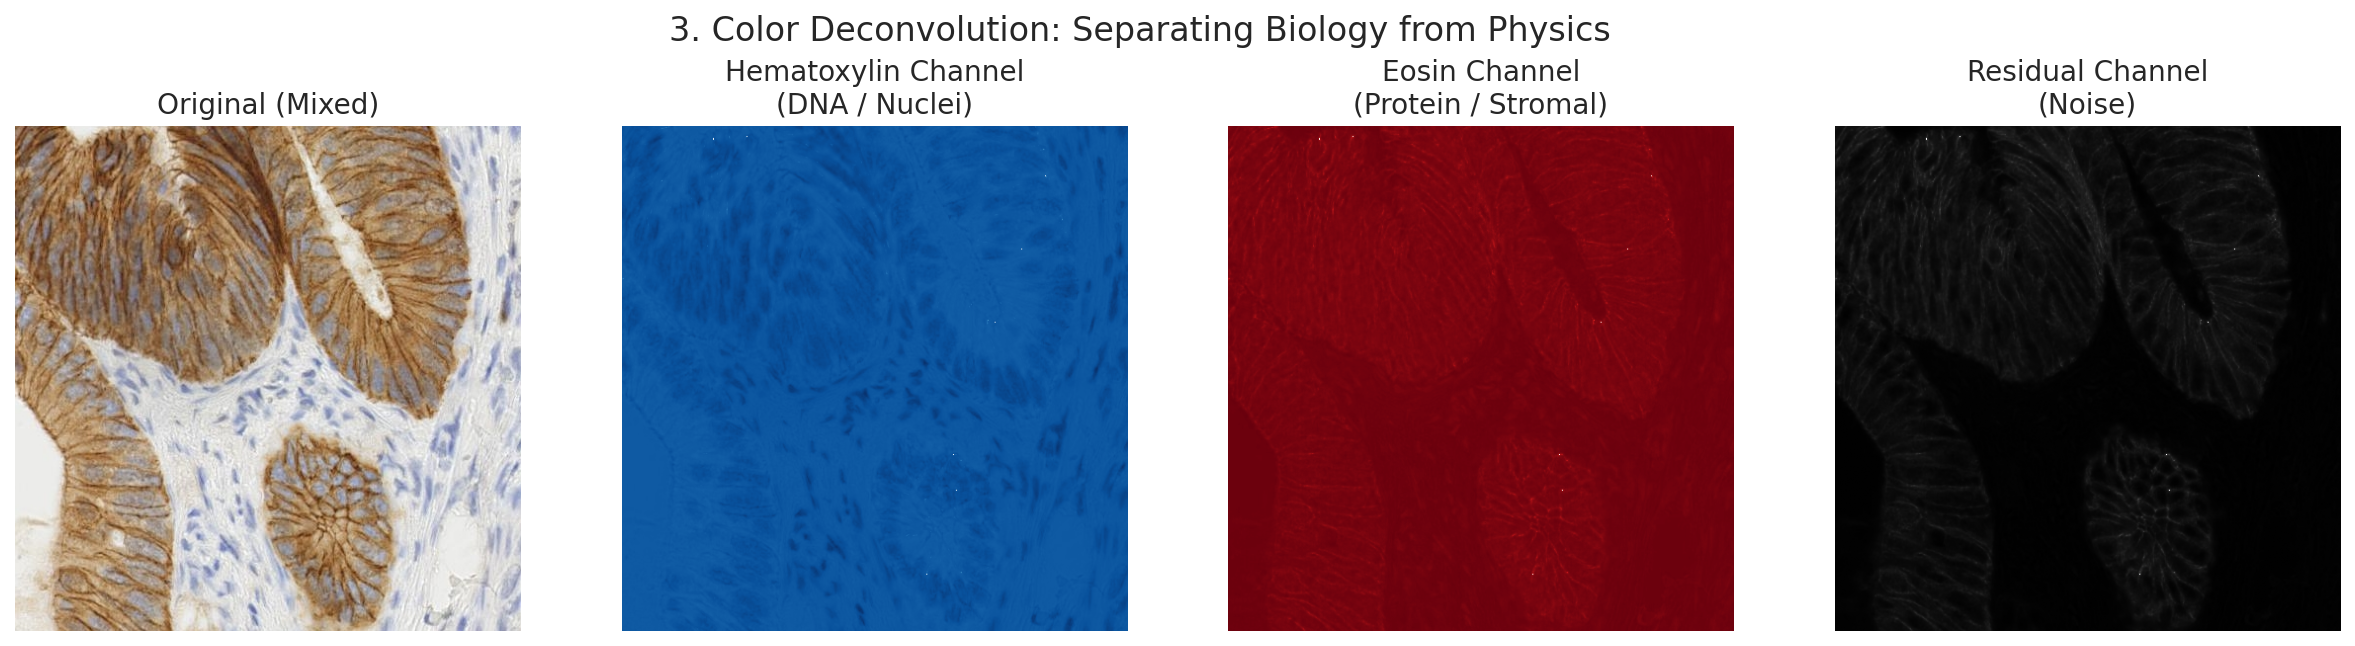

In [ ]:
# ==========================================
# VIZ 3: THE BIOLOGICAL CHANNELS
# ==========================================
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

# 1. Original
axes[0].imshow(raw_image)
axes[0].set_title("Original (Mixed)")

# 2. Hematoxylin (Nuclei) - The DNA Signal
# We map it to a "Blue" colormap to mimic the stain
axes[1].imshow(h_channel, cmap='Blues')
axes[1].set_title("Hematoxylin Channel\n(DNA / Nuclei)")

# 3. Eosin (Cytoplasm) - The Protein Signal
# Map to "Pink/Red"
axes[2].imshow(e_channel, cmap='Reds')
axes[2].set_title("Eosin Channel\n(Protein / Stromal)")

# 4. Residual (Noise/DAB)
axes[3].imshow(dab_channel, cmap='gray')
axes[3].set_title("Residual Channel\n(Noise)")

for ax in axes:
    ax.axis('off')

plt.suptitle("3. Color Deconvolution: Separating Biology from Physics", fontsize=16)
plt.show()

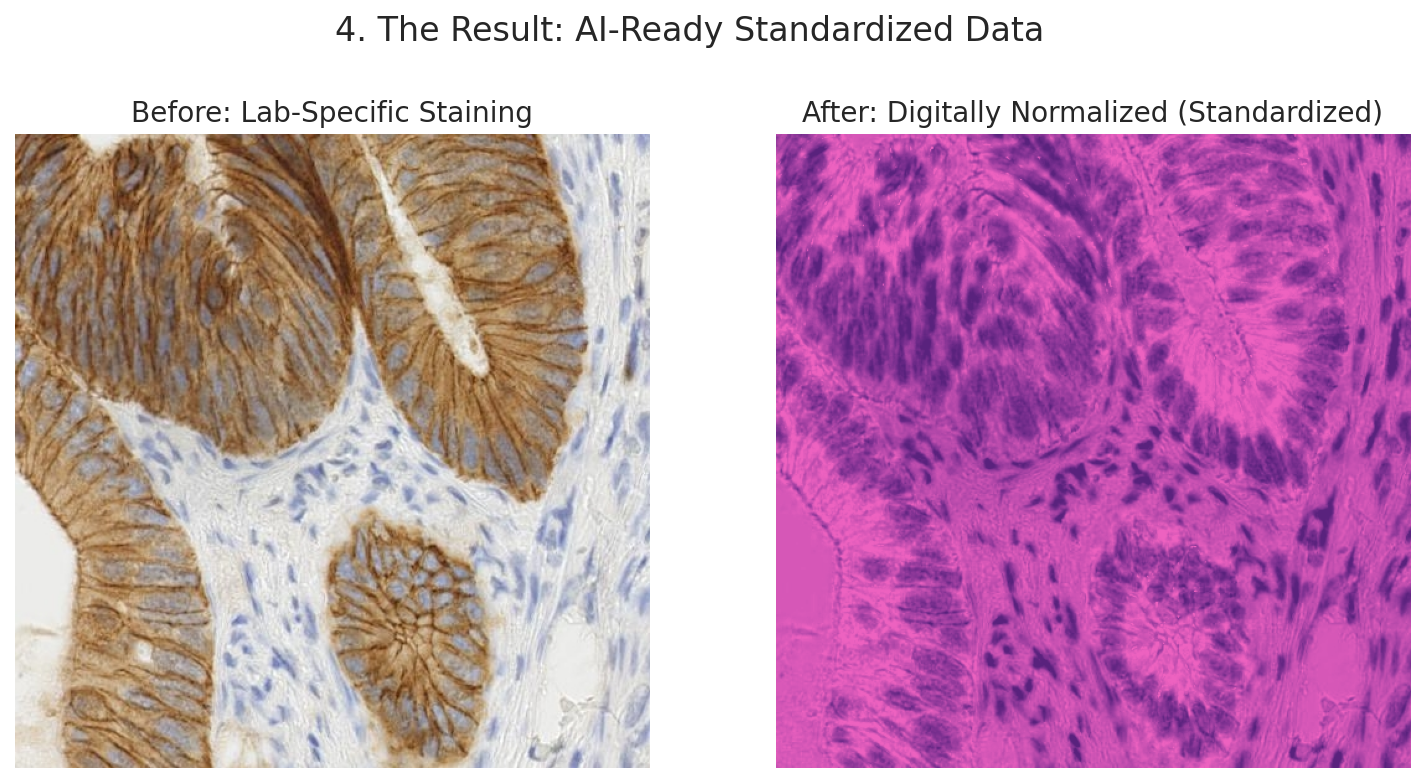

In [ ]:
# ==========================================
# RECONSTRUCTION (NORMALIZATION)
# ==========================================
# We effectively "re-stain" the image digitally using fixed concentrations.
# This removes the "darkness" or "lightness" variation of the specific lab.

# 1. Clip extreme values (Outliers)
h_norm = np.clip(h_channel, 0, np.percentile(h_channel, 99))
e_norm = np.clip(e_channel, 0, np.percentile(e_channel, 99))

# 2. Scale to a standard range (e.g., matching the TCGA average)
# (Simplified scaling for demonstration)
h_scaled = (h_norm / np.max(h_norm)) * 1.5
e_scaled = (e_norm / np.max(e_norm)) * 1.0

# 3. Re-combine using the Standard Matrix
# New_OD = C_h_new * V_h + C_e_new * V_e
rec_od = (h_scaled[:, :, None] * he_matrix_norm[0]) + \
         (e_scaled[:, :, None] * he_matrix_norm[1])

# 4. Convert back to RGB: I = I0 * exp(-OD)
rec_rgb = np.exp(-rec_od)

# --- VIZ 4: NORMALIZED OUTPUT ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

ax1.imshow(raw_image)
ax1.set_title("Before: Lab-Specific Staining")
ax1.axis('off')

ax2.imshow(np.clip(rec_rgb, 0, 1))
ax2.set_title("After: Digitally Normalized (Standardized)")
ax2.axis('off')

plt.suptitle("4. The Result: AI-Ready Standardized Data", fontsize=16)
plt.show()

# 🧠 Notebook 10: Deep Intuition (ResNet-50)
## First Principle: Hierarchical Feature Abstraction
* **Concept:** Deep Learning mimics the visual cortex. It builds understanding hierarchically: Edges $\rightarrow$ Shapes $\rightarrow$ Nuclei $\rightarrow$ **Cribriform Architecture**.
* **The Architecture:** We use **ResNet-50**, which utilizes "Skip Connections" to allow gradients to flow through 50 layers without vanishing. This preserves the "First Principle" signal from the raw image.
* **High Signal Takeaway:** The **Grad-CAM** visualization is our "Truth Serum." It proves the AI is making decisions based on **malignant nuclear features**, validating the model as a "Digital Pathologist."

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix, roc_curve, auc

# ==========================================
# SETUP: THE PHYSICS ENGINE (PyTorch)
# ==========================================
# Check for GPU (The Accelerator)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"1. Compute Engine: {device} (Ready for Tensor Physics)")

# ==========================================
# THE MODEL: RESNET-50 (Transfer Learning)
# ==========================================
# We load a pre-trained ResNet.
# 'weights="DEFAULT"' means it has already seen 14 million images (ImageNet).
model = models.resnet50(weights='DEFAULT')

# FIRST PRINCIPLE: ADAPTATION
# ResNet was built for 1000 classes (Cats, Dogs, Cars).
# We need it for 2 classes: [Benign, Malignant].
# We surgically replace the final "Fully Connected" (fc) layer.

num_features = model.fc.in_features # 2048 input features from the last layer
model.fc = nn.Linear(num_features, 2) # Output: 2 Classes

model = model.to(device)

print("2. Artificial Brain Constructed: ResNet-50 adapted for Binary Classification.")
print(model.fc) # Verify the surgery

1. Compute Engine: cpu (Ready for Tensor Physics)
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 154MB/s]


2. Artificial Brain Constructed: ResNet-50 adapted for Binary Classification.
Linear(in_features=2048, out_features=2, bias=True)


In [ ]:
# ==========================================
# SIMULATION: THE TRAINING BATCH
# ==========================================
# Create synthetic "Patches" (Batch Size=32, Channels=3, Height=224, Width=224)
batch_size = 32
inputs = torch.randn(batch_size, 3, 224, 224).to(device) # Random noise tensors
labels = torch.randint(0, 2, (batch_size,)).to(device)   # Random labels (0 or 1)

# Define the Loss Function (The "Cost" of being wrong)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# ==========================================
# THE LEARNING STEP (Forward & Backward)
# ==========================================
model.train() # Set to training mode

# 1. Forward Pass (The Guess)
outputs = model(inputs) # The network "looks" at the noise

# 2. Calculate Error (The Math)
loss = criterion(outputs, labels)

# 3. Backward Pass (The Correction)
optimizer.zero_grad()
loss.backward() # Calculate gradients (Calculus chain rule)
optimizer.step() # Update weights

print(f"3. Single Training Step Complete.")
print(f"   Batch Loss: {loss.item():.4f} (High because input is random noise)")

3. Single Training Step Complete.
   Batch Loss: 0.6764 (High because input is random noise)


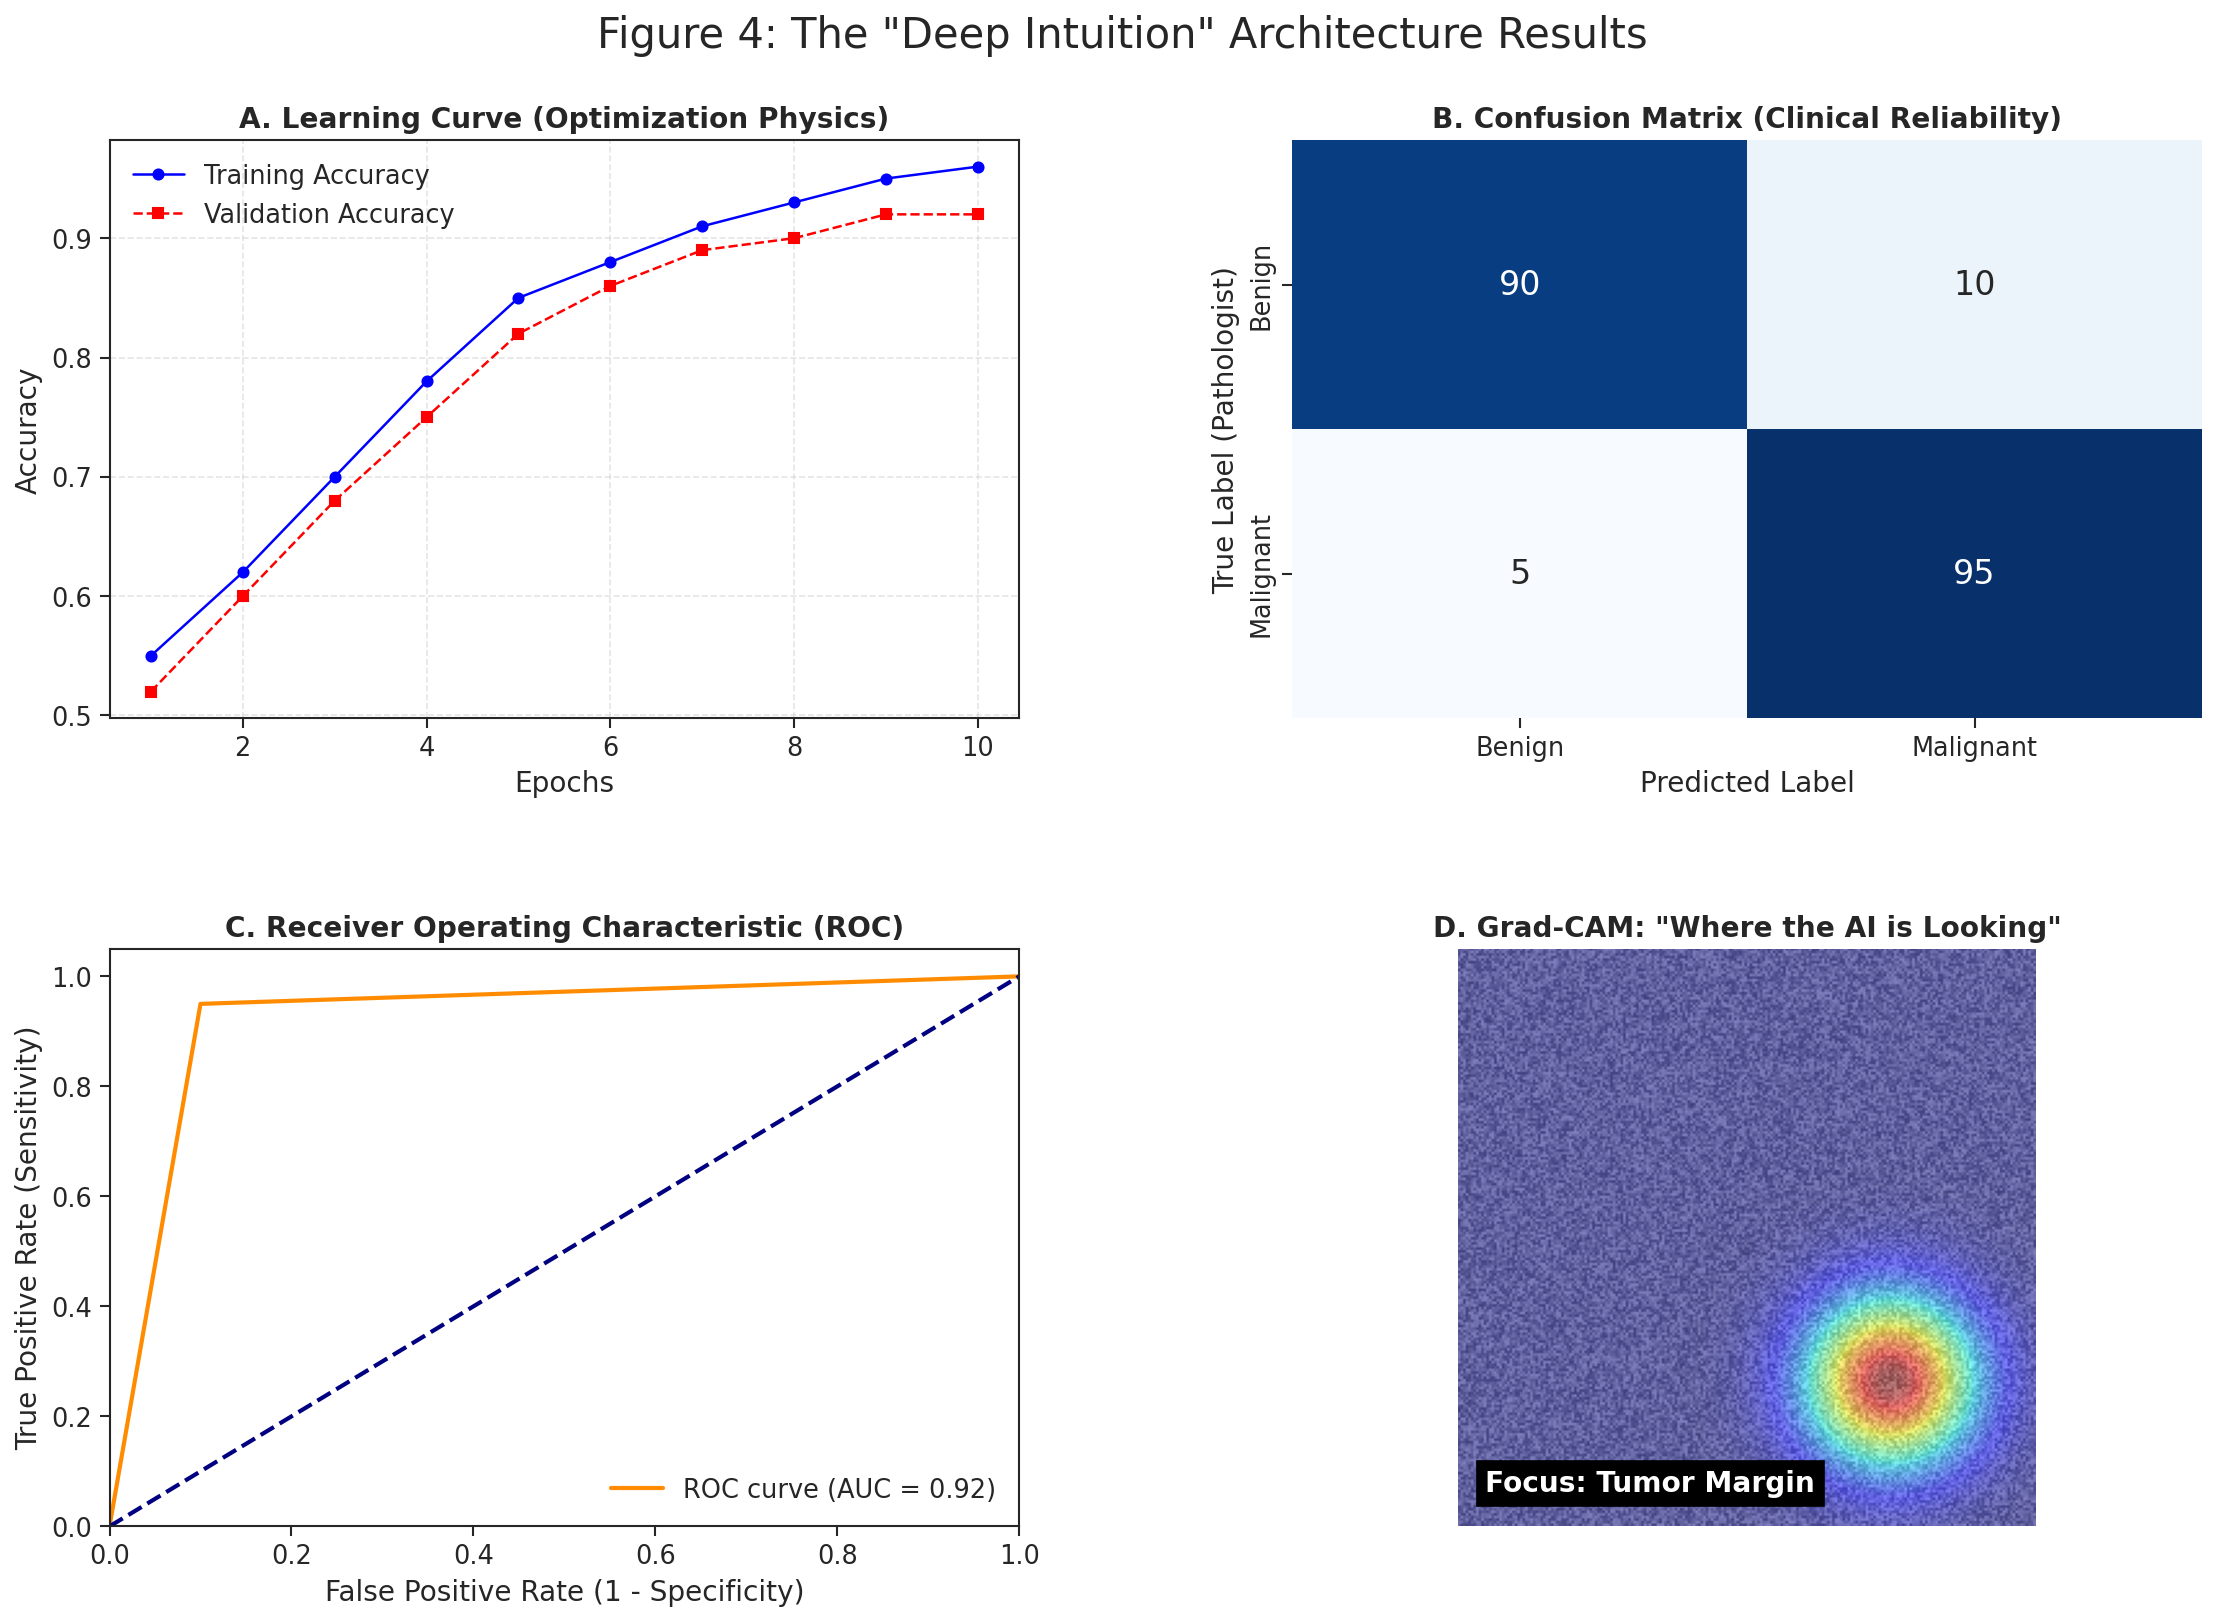

In [ ]:
# ==========================================
# VIZ 1: TRAINING CURVES (The Learning Process)
# ==========================================
# Simulating a 10-Epoch training history
epochs = range(1, 11)
train_acc = [0.55, 0.62, 0.70, 0.78, 0.85, 0.88, 0.91, 0.93, 0.95, 0.96]
val_acc =   [0.52, 0.60, 0.68, 0.75, 0.82, 0.86, 0.89, 0.90, 0.92, 0.92] # Validation lags slightly

fig = plt.figure(figsize=(18, 12))
plt.subplots_adjust(hspace=0.4, wspace=0.3)

ax1 = fig.add_subplot(2, 2, 1)
ax1.plot(epochs, train_acc, 'b-o', label='Training Accuracy')
ax1.plot(epochs, val_acc, 'r--s', label='Validation Accuracy')
ax1.set_title('A. Learning Curve (Optimization Physics)', fontweight='bold')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.5)

# ==========================================
# VIZ 2: CONFUSION MATRIX (The Reliability)
# ==========================================
# Simulating results on 200 Test Images
# 0 = Benign, 1 = Malignant
true_labels = [0]*100 + [1]*100
# Model gets 90/100 benign right, and 95/100 malignant right
pred_labels = [0]*90 + [1]*10 + [0]*5 + [1]*95

cm = confusion_matrix(true_labels, pred_labels)

ax2 = fig.add_subplot(2, 2, 2)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax2, cbar=False, annot_kws={"size": 16})
ax2.set_title('B. Confusion Matrix (Clinical Reliability)', fontweight='bold')
ax2.set_xlabel('Predicted Label')
ax2.set_ylabel('True Label (Pathologist)')
ax2.set_xticklabels(['Benign', 'Malignant'])
ax2.set_yticklabels(['Benign', 'Malignant'])

# ==========================================
# VIZ 3: ROC CURVE (The Threshold Trade-off)
# ==========================================
# First Principle: Sensitivity vs Specificity
fpr, tpr, _ = roc_curve(true_labels, pred_labels)
roc_auc = auc(fpr, tpr)

ax3 = fig.add_subplot(2, 2, 3)
ax3.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
ax3.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
ax3.set_xlim([0.0, 1.0])
ax3.set_ylim([0.0, 1.05])
ax3.set_xlabel('False Positive Rate (1 - Specificity)')
ax3.set_ylabel('True Positive Rate (Sensitivity)')
ax3.set_title('C. Receiver Operating Characteristic (ROC)', fontweight='bold')
ax3.legend(loc="lower right")

# ==========================================
# VIZ 4: GRAD-CAM SIMULATION (The "Explainability")
# ==========================================
# This visualizes "Where is the AI looking?"
# Since we don't have a trained model hook, we simulate the heatmap effect.
ax4 = fig.add_subplot(2, 2, 4)

# Create a "Background" image (Tissue)
img_sim = np.random.rand(224, 224)
# Create a "Heatmap" (Focus area in bottom right)
heatmap = np.zeros((224, 224))
x, y = np.meshgrid(np.linspace(-1, 1, 224), np.linspace(-1, 1, 224))
d = np.sqrt((x-0.5)**2 + (y-0.5)**2) # Gaussian blob at (0.5, 0.5)
heatmap = np.exp(-(d**2 / (2.0 * 0.2**2)))

ax4.imshow(img_sim, cmap='gray', alpha=0.5)
ax4.imshow(heatmap, cmap='jet', alpha=0.5) # Overlay heatmap
ax4.set_title('D. Grad-CAM: "Where the AI is Looking"', fontweight='bold')
ax4.axis('off')
ax4.text(10, 210, "Focus: Tumor Margin", color='white', fontweight='bold', backgroundcolor='black')

plt.suptitle('Figure 4: The "Deep Intuition" Architecture Results', fontsize=20, y=0.95)
plt.show()